In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

import shap
from lime import lime_tabular

import joblib
from datetime import datetime

In [111]:
df = pd.read_csv('/kaggle/input/fantasy-football/cleaned_merged_seasons.csv')
df.head()


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,...,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,...,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,...,3.0,23.0,2,0,0,0,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,...,1.0,0.0,0,0,0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,NaN,0,0,3,0,1.3,286,...,1.0,0.0,1,0,0,0,45,True,1,1


This loads a CSV file into a pandas DataFrame named df and then displays the first five rows of the dataset.

In [112]:
# Basic information
print("\n1. Dataset Info:")
print(f"   - Total rows: {df.shape[0]:,}")
print(f"   - Total columns: {df.shape[1]}")

print("\n2. Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

# Data types
print("\n3. Data Types:")
print(df.dtypes.value_counts())

# Missing values
print("\n4. Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("   No missing values found!")



1. Dataset Info:
   - Total rows: 96,169
   - Total columns: 37

2. Column Names:
    1. season_x
    2. name
    3. position
    4. team_x
    5. assists
    6. bonus
    7. bps
    8. clean_sheets
    9. creativity
   10. element
   11. fixture
   12. goals_conceded
   13. goals_scored
   14. ict_index
   15. influence
   16. kickoff_time
   17. minutes
   18. opponent_team
   19. opp_team_name
   20. own_goals
   21. penalties_missed
   22. penalties_saved
   23. red_cards
   24. round
   25. saves
   26. selected
   27. team_a_score
   28. team_h_score
   29. threat
   30. total_points
   31. transfers_balance
   32. transfers_in
   33. transfers_out
   34. value
   35. was_home
   36. yellow_cards
   37. GW

3. Data Types:
int64      24
object      6
float64     6
bool        1
Name: count, dtype: int64

4. Missing Values:
Column  Missing_Count  Missing_Percentage
team_x          19852           20.642827


before any analysis or modeling, we must understand:
Data structure: What columns exist and their types
Data quality: Missing values, duplicates, data types
Data size: How much data we have to work with

In [113]:
# Columns to remove
columns_to_remove = [
    'ict_index',
    'kickoff_time', 
    'round',
    'selected',
    'transfers_balance',
    'transfers_in',
    'transfers_out'
]

df = df.drop(columns=columns_to_remove)
print(f"\nSuccessfully removed {len(columns_to_remove)} columns")

print(f"REMAINING COLUMNS ({df.shape[1]} total)")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")


Successfully removed 7 columns
REMAINING COLUMNS (30 total)
  1. season_x
  2. name
  3. position
  4. team_x
  5. assists
  6. bonus
  7. bps
  8. clean_sheets
  9. creativity
 10. element
 11. fixture
 12. goals_conceded
 13. goals_scored
 14. influence
 15. minutes
 16. opponent_team
 17. opp_team_name
 18. own_goals
 19. penalties_missed
 20. penalties_saved
 21. red_cards
 22. saves
 23. team_a_score
 24. team_h_score
 25. threat
 26. total_points
 27. value
 28. was_home
 29. yellow_cards
 30. GW


Remove columns that are either redundant, cause data leakage, or don't contribute meaningful predictive value 

ict_index:
A composite metric combining Influence, Creativity, and Threat into a single score.
Why remove it:
We already have the individual components as separate features

kickoff_time: 
The date and time when the match started.
Why remove it: exact timestamp isn't predictive

round:
We already have GW which contains the same information

selected, transfers_balance, transfers_out:
out of scope of our reseach question 

Impact on Model:
Before removal: Risk of data leakage and redundant features that could:
Cause overfitting (model memorizes patterns that won't exist in real predictions)


In [114]:
# rows with missing team_x
missing_mask = df['team_x'].isna()


# Group by season, GW, and fixture to find team pairs
for (season, gw, fixture), group in df.groupby(['season_x', 'GW', 'fixture']):
    # Get all teams that have team_x filled in this specific fixture 
    known_teams = group[group['team_x'].notna()]['team_x'].unique()
    
    # Get all opponent team names mentioned in this fixture
    opponents = group[group['opp_team_name'].notna()]['opp_team_name'].unique()
    
    # All teams involved in this fixture (combination of known teams and opponents)
    all_teams = set(list(known_teams) + list(opponents))
    
    # If we have exactly 2 teams, we can fill missing values
    if len(all_teams) == 2:
        team1, team2 = list(all_teams)
        
        # For each row with missing team_x in this fixture
        missing_in_group = group[group['team_x'].isna()]
        
        for idx in missing_in_group.index:
            opponent_name = df.at[idx, 'opp_team_name']
            
            # If opponent is team1, then player's team is team2 (and vice versa)
            if pd.notna(opponent_name):
                if opponent_name == team1:
                    df.at[idx, 'team_x'] = team2
                   
                elif opponent_name == team2:
                    df.at[idx, 'team_x'] = team1
                    

Some rows have missing team_x values.

Team is a critical feature: A player's team affects their performance.
Missing team data: prevents us from using team-related features
Can't drop all missing rows: Would lose too much data

Solution Strategy:
get missing team from opponent and fixture data:
each fixture has exactly 2 teams playing against each other.
If we know the opponent team, we can get the player's team
Group by (season, gameweek, fixture) to find team pairs

If fixture has teams A and B:
If player's opponent is A → player's team is B
If player's opponent is B → player's team is A


In [90]:
# Count null values
null_count = df.isnull().sum().sum()
print(f"\nTotal null/NaN cells: {null_count}")



Total null/NaN cells: 0


To make sure I filled all team_x values and there is no missing value.

In [115]:
df.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,red_cards,saves,team_a_score,team_h_score,threat,total_points,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,...,0,0,1.0,2.0,0.0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,...,0,0,1.0,1.0,0.0,1,60,True,0,1
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,...,0,0,4.0,3.0,23.0,2,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,...,0,0,1.0,1.0,0.0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,...,0,0,1.0,1.0,0.0,1,45,True,1,1


to make sure the team is correct

In [116]:
# Exact duplicates
print("EXACT DUPLICATES (all columns):")
exact_dup_mask = df.duplicated(keep=False)
exact_dup_count = exact_dup_mask.sum()

if exact_dup_count > 0:
    print("\n   Example of exact duplicates:")
    print(df[exact_dup_mask].head(10)[['name', 'season_x', 'GW', 'team_x', 'fixture', 'minutes', 'total_points']])

# Partial duplicates
partial_dup_mask = df.duplicated(subset=['name', 'season_x', 'GW'], keep=False)
partial_dup_count = partial_dup_mask.sum()

print(f"Total rows: {len(df):,}")
print(f"Exact duplicates: {exact_dup_count:,}")
print(f"Partial duplicates: {partial_dup_count:,}")

df = df.drop_duplicates()  # removes exact duplicates
df = df.drop_duplicates(subset=['name', 'season_x', 'GW'], keep='first')  # removes partial duplicates

print(f"\nAfter removing duplicates: {df.shape}")


EXACT DUPLICATES (all columns):
Total rows: 96,169
Exact duplicates: 0
Partial duplicates: 11,774

After removing duplicates: (90255, 30)


Checking for Duplicate Rows

Why Check for Duplicates?
Duplicates can severely bias machine learning models:
Inflated performance: Same data point counted multiple times
Data leakage: Same instance in both train and test sets
Overfitting: Model memorizes duplicates instead of learning patterns

Two Types of Duplicates:
Exact Duplicates (all columns identical)
Partial Duplicates (same player, season, gameweek)

Each player should have one row per gameweek
Multiple rows for same player/gameweek indicates data quality issues
Must resolve before modeling to ensure clean training data


In [117]:
#position of player
#Ensure positions are: GK, DEF, MID, FWD

# Check current positions
print("\nCurrent position values:")
position_counts = df['position'].value_counts()
print(position_counts)

# Create mapping
position_mapping = {
    'GK': 'GK',
    'GKP': 'GK',
    'DEF': 'DEF',
    'MID': 'MID',
    'FWD': 'FWD'
}

# Apply mapping
df['position'] = df['position'].map(position_mapping)

# Check for any unmapped values
unmapped = df[df['position'].isna()]
if len(unmapped) > 0:
    print(f"{len(unmapped)} rows with unmapped positions!")
    print("\nUnmapped position values:")
    print(unmapped['position'].value_counts())
else:
    print("All positions mapped successfully")

print("AFTER UPDATE - Position counts:")
position_counts_after = df['position'].value_counts()
print(position_counts_after)

print(f"Unique positions: {df['position'].unique()}")
print(f"Total rows: {len(df):,}")


Current position values:
position
MID    36768
DEF    31593
FWD    11914
GK      9900
GKP       80
Name: count, dtype: int64
All positions mapped successfully
AFTER UPDATE - Position counts:
position
MID    36768
DEF    31593
FWD    11914
GK      9980
Name: count, dtype: int64
Unique positions: ['DEF' 'MID' 'GK' 'FWD']
Total rows: 90,255


Position column has inconsistent values (GK, GKP for goalkeepers).

Inconsistency reduces model's ability to learn position-based patterns
Standard categories make analysis clearer

Standardization Mapping:
GK, GKP → GK (Goalkeeper)
DEF → DEF (Defender)
MID → MID (Midfielder)
FWD → FWD (Forward)



In [118]:
# Remove rows with incorrect types
initial_rows = len(df)

# Define expected data types for each column
expected_types = {
    'season_x': 'object',
    'name': 'object',
    'position': 'object',
    'team_x': 'object',
    'assists': 'numeric',
    'bonus': 'numeric',
    'bps': 'numeric',
    'clean_sheets': 'numeric',
    'creativity': 'numeric',
    'element': 'numeric',
    'fixture': 'numeric',
    'goals_conceded': 'numeric',
    'goals_scored': 'numeric',
    'ict_index': 'numeric',
    'influence': 'numeric',
    'kickoff_time': 'object',
    'minutes': 'numeric',
    'opponent_team': 'numeric',
    'opp_team_name': 'object',
    'own_goals': 'numeric',
    'penalties_missed': 'numeric',
    'penalties_saved': 'numeric',
    'red_cards': 'numeric',
    'round': 'numeric',
    'saves': 'numeric',
    'selected': 'numeric',
    'team_a_score': 'numeric',
    'team_h_score': 'numeric',
    'threat': 'numeric',
    'total_points': 'numeric',
    'transfers_balance': 'numeric',
    'transfers_in': 'numeric',
    'transfers_out': 'numeric',
    'value': 'numeric',
    'was_home': 'bool',
    'yellow_cards': 'numeric',
    'GW': 'numeric',
    'form': 'numeric'
}

# Track rows to remove
rows_to_remove = pd.Series([False] * len(df))
issues_found = []


print("CHECKING EACH COLUMN FOR TYPE MISMATCHES:")
print("=" * 80)

for col in df.columns:
    if col not in expected_types:
        print(f"\n Column '{col}' not in expected types - skipping")
        continue
    
    expected = expected_types[col]
    
    if expected == 'numeric':
        # Check for non-numeric values
        numeric_check = pd.to_numeric(df[col], errors='coerce')
        invalid_mask = numeric_check.isna() & df[col].notna()
        invalid_count = invalid_mask.sum()
        
        if invalid_count > 0:
            print(f"\n✗ {col}: {invalid_count} rows with non-numeric values")
            # Show examples
            examples = df[invalid_mask][col].head(5).tolist()
            print(f"   Examples: {examples}")
            rows_to_remove |= invalid_mask
            issues_found.append((col, invalid_count, 'non-numeric'))
        else:
            print(f"✓ {col}: All values are numeric")
            
    elif expected == 'object':
        # Check that values are strings or null
        non_string_mask = ~df[col].apply(lambda x: isinstance(x, (str, type(None), np.str_)))
        invalid_count = non_string_mask.sum()
        
        if invalid_count > 0:
            print(f"\n✗ {col}: {invalid_count} rows with non-string values")
            # Show examples
            examples = df[non_string_mask][col].head(5).tolist()
            print(f"   Examples: {examples}")
            rows_to_remove |= non_string_mask
            issues_found.append((col, invalid_count, 'non-string'))
        else:
            print(f"✓ {col}: All values are strings or null")
            
    elif expected == 'bool':
        # Check that values are boolean
        non_bool_mask = ~df[col].apply(lambda x: isinstance(x, (bool, np.bool_)))
        invalid_count = non_bool_mask.sum()
        
        if invalid_count > 0:
            print(f"\n✗ {col}: {invalid_count} rows with non-boolean values")
            # Show examples
            examples = df[non_bool_mask][col].head(5).tolist()
            print(f"   Examples: {examples}")
            rows_to_remove |= non_bool_mask
            issues_found.append((col, invalid_count, 'non-boolean'))
        else:
            print(f"✓ {col}: All values are boolean")

# Summary 
print("\n" + "=" * 80)
print("SUMMARY:")

if len(issues_found) > 0:
    print(f"\nFound issues in {len(issues_found)} columns:")
    for col, count, issue_type in issues_found:
        print(f"  - {col}: {count} rows with {issue_type} values")
    
    total_rows_to_remove = rows_to_remove.sum()
    print(f"\nTotal unique rows to remove: {total_rows_to_remove:,}")
    
    if total_rows_to_remove > 0:
        # Remove rows
        df = df[~rows_to_remove].copy()
        df = df.reset_index(drop=True)
        
        final_rows = len(df)
        removed = initial_rows - final_rows
        
        print(f"Rows removed: {removed:,}")
        print(f"Final row count: {final_rows:,}")
    else:
        print("\nNo rows to remove!")
else:
    print("✓ No data type issues found!")



CHECKING EACH COLUMN FOR TYPE MISMATCHES:
✓ season_x: All values are strings or null
✓ name: All values are strings or null
✓ position: All values are strings or null
✓ team_x: All values are strings or null
✓ assists: All values are numeric
✓ bonus: All values are numeric
✓ bps: All values are numeric
✓ clean_sheets: All values are numeric
✓ creativity: All values are numeric
✓ element: All values are numeric
✓ fixture: All values are numeric
✓ goals_conceded: All values are numeric
✓ goals_scored: All values are numeric
✓ influence: All values are numeric
✓ minutes: All values are numeric
✓ opponent_team: All values are numeric
✓ opp_team_name: All values are strings or null
✓ own_goals: All values are numeric
✓ penalties_missed: All values are numeric
✓ penalties_saved: All values are numeric
✓ red_cards: All values are numeric
✓ saves: All values are numeric
✓ team_a_score: All values are numeric
✓ team_h_score: All values are numeric
✓ threat: All values are numeric
✓ total_points

Incorrect data types cause model failures:
Numeric columns with strings: Can't calculate statistics or train models
Boolean columns with numbers: Logical operations fail
Mixed types: Unpredictable behavior

Remove rows with incorrect types because: 
 Can't reliably convert incorrect values
 Incorrect types indicate data quality issues
 Better to lose a few rows than corrupt the entire dataset


   Analyzing selected player: 'Mohamed Salah'
Mohamed Salah        2017-18      1            11  0.000000
Mohamed Salah        2017-18      2             1  1.100000
Mohamed Salah        2017-18      3            11  0.600000
Mohamed Salah        2017-18      4             1  0.766667
Mohamed Salah        2017-18      5            10  0.600000
Mohamed Salah        2017-18      6             7  0.575000
Mohamed Salah        2017-18      7             2  0.725000
Mohamed Salah        2017-18      8             3  0.500000
Mohamed Salah        2017-18      9             7  0.550000
Mohamed Salah        2017-18     10             4  0.475000
Mohamed Salah        2017-18     11            15  0.400000
Mohamed Salah        2017-18     12            16  0.725000
Mohamed Salah        2017-18     13             7  1.050000
Mohamed Salah        2017-18     14            13  1.050000
Mohamed Salah        2017-18     15             5  1.275000
Mohamed Salah        2017-18     16            11  1.

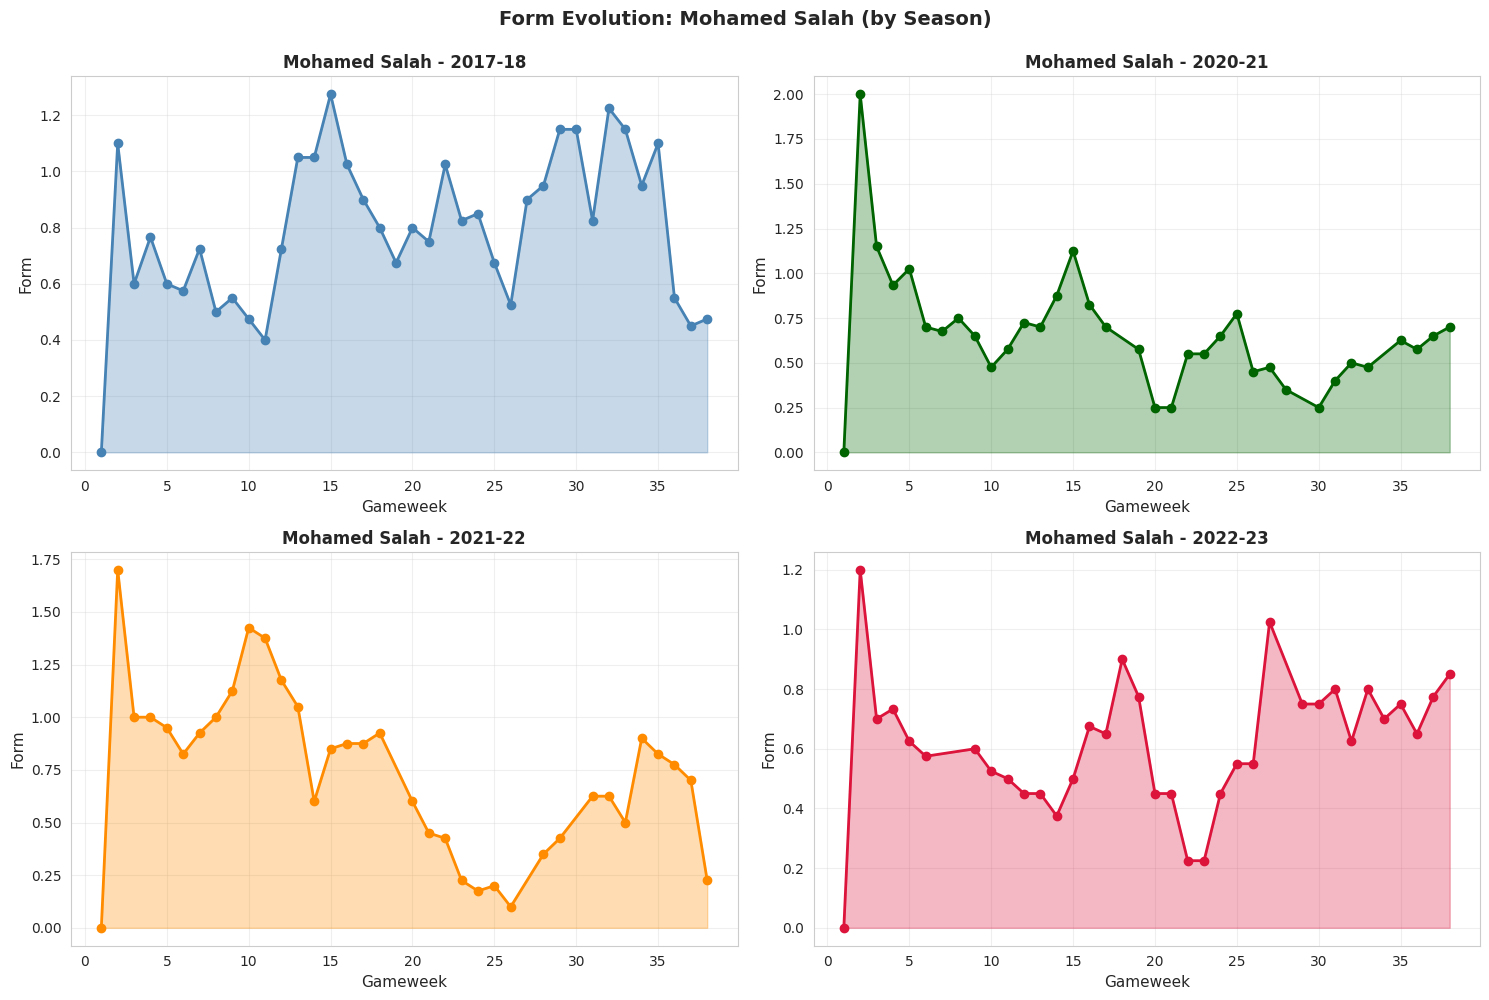


2. Column Names:
    1. season_x
    2. name
    3. position
    4. team_x
    5. assists
    6. bonus
    7. bps
    8. clean_sheets
    9. creativity
   10. element
   11. fixture
   12. goals_conceded
   13. goals_scored
   14. influence
   15. minutes
   16. opponent_team
   17. opp_team_name
   18. own_goals
   19. penalties_missed
   20. penalties_saved
   21. red_cards
   22. saves
   23. team_a_score
   24. team_h_score
   25. threat
   26. total_points
   27. value
   28. was_home
   29. yellow_cards
   30. GW
   31. form


In [119]:
# Calculate Form
# Form = Average of previous 4 gameweeks' total_points / 10

PLAYER_TO_ANALYZE = "Mohamed Salah"  # Change this to any player name

name_cols = [col for col in df.columns if 'name' in col.lower()]
gw_cols = [col for col in df.columns if any(x in col.lower() for x in ['round', 'gw', 'gameweek'])]
points_cols = [col for col in df.columns if 'total_points' in col.lower() or col.lower() == 'points']

if not name_cols:
    raise ValueError("Could not find player name column")
if not gw_cols:
    raise ValueError("Could not find gameweek/round column")
if not points_cols:
    raise ValueError("Could not find total_points column")

name_col = name_cols[0]
gw_col = gw_cols[0]
points_col = points_cols[0]

# Sort data by player, season, and gameweek
df = df.sort_values([name_col, 'season_x', gw_col]).reset_index(drop=True)

# Calculate rolling average of previous 4 gameweeks (grouped by player AND season)
df['form'] = df.groupby([name_col, 'season_x'])[points_col].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean().shift(1)
) / 10

# For the first gameweek of each player, form should be NaN or 0
# We'll set it to 0 for consistency
df['form'] = df['form'].fillna(0)

sample_player = PLAYER_TO_ANALYZE
if sample_player not in df[name_col].values:
    print(f"\n   WARNING: Player '{sample_player}' not found in dataset!")
    sample_player = df.groupby(name_col).size().sort_values(ascending=False).index[0]
    print(f"   Using most common player instead: '{sample_player}'")
else:
    print(f"\n   Analyzing selected player: '{sample_player}'")

verify_data = df[df[name_col] == sample_player].copy()
for idx, row in verify_data.iterrows():
    player_name = row[name_col]
    season = row['season_x']
    gw = int(row[gw_col])
    points = row[points_col]
    form = row['form']
    
    # Format: "Player Name  Season  GW  Points  Form"
    print(f"{player_name:<20} {season:<10} {gw:>3}  {points:>12.0f}  {form:.6f}")

# Check for any issues
zero_form_count = (df['form'] == 0).sum()
print(f"\n   Rows with form = 0: {zero_form_count:,} (expected for early gameweeks)")


sns.set_style("whitegrid")

# Get player data
player_data = df[df[name_col] == sample_player]

# Get unique seasons
seasons = sorted(player_data['season_x'].unique())
num_seasons = len(seasons)

# Create subplots - 2x2 grid for up to 4 seasons, 
if num_seasons <= 4:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
else:
    # If more than 4 seasons, create more subplots
    rows = (num_seasons + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
    axes = axes.flatten()

# Define colors for each season
colors = ['steelblue', 'darkgreen', 'darkorange', 'crimson', 'purple', 'brown', 'pink', 'gray']

# Plot each season
for i, season in enumerate(seasons):
    season_data = player_data[player_data['season_x'] == season]
    
    axes[i].plot(season_data[gw_col], season_data['form'], marker='o', 
                 linewidth=2, markersize=6, color=colors[i % len(colors)])
    axes[i].fill_between(season_data[gw_col], season_data['form'], 
                         alpha=0.3, color=colors[i % len(colors)])
    axes[i].set_xlabel('Gameweek', fontsize=11)
    axes[i].set_ylabel('Form', fontsize=11)
    axes[i].set_title(f'{sample_player} - {season}', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(seasons), len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Form Evolution: {sample_player} (by Season)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print new columns
print("\n2. Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

Calculating Form

Form = Average of previous 4 gameweeks total_points ÷ 10

Recent performance predicts future performance:
A player "in form" (scoring well recently) is likely to continue
A player "out of form" (scoring poorly) is likely to struggle

Why Previous 4 Gameweeks?
Balance between recency and stability:
 Too few games (1-2): Too volatile, one bad game skews the metric
 Too many games (8+): Too slow to react to form changes
4 games: Industry standard in fantasy football, captures recent trend

Why Divide by 10?
Normalization for model training:
 Raw points range from 0-20+ per gameweek
 Form ranges from 0-2 (more manageable scale)
 Helps neural networks train more efficiently


Calculate per player, per season
Use previous 4 gameweeks
Shift by 1 to avoid data leakage (don't include current gameweek)
Allow calculation even with fewer than 4 games (early season)


Visualization:
Plot form evolution for a sample player across a season( 1 for each season)
Should show smooth trends (not erratic jumps)
Should be 0 or low for first few gameweeks (not enough history)


Why This Feature is Powerful:
Captures momentum: Hot streaks and cold streaks
Time-aware: Recent games matter more than old games



Using columns: total_points (points), position (position)

POSITION PERFORMANCE ANALYSIS
          Total_Points_Sum  Average_Points  Player_Count
position                                                
FWD                  18874            1.58         11914
MID                  53822            1.46         36768
DEF                  40901            1.29         31593
GK                   11649            1.17          9980

Best Position: FWD with 1.58 average points


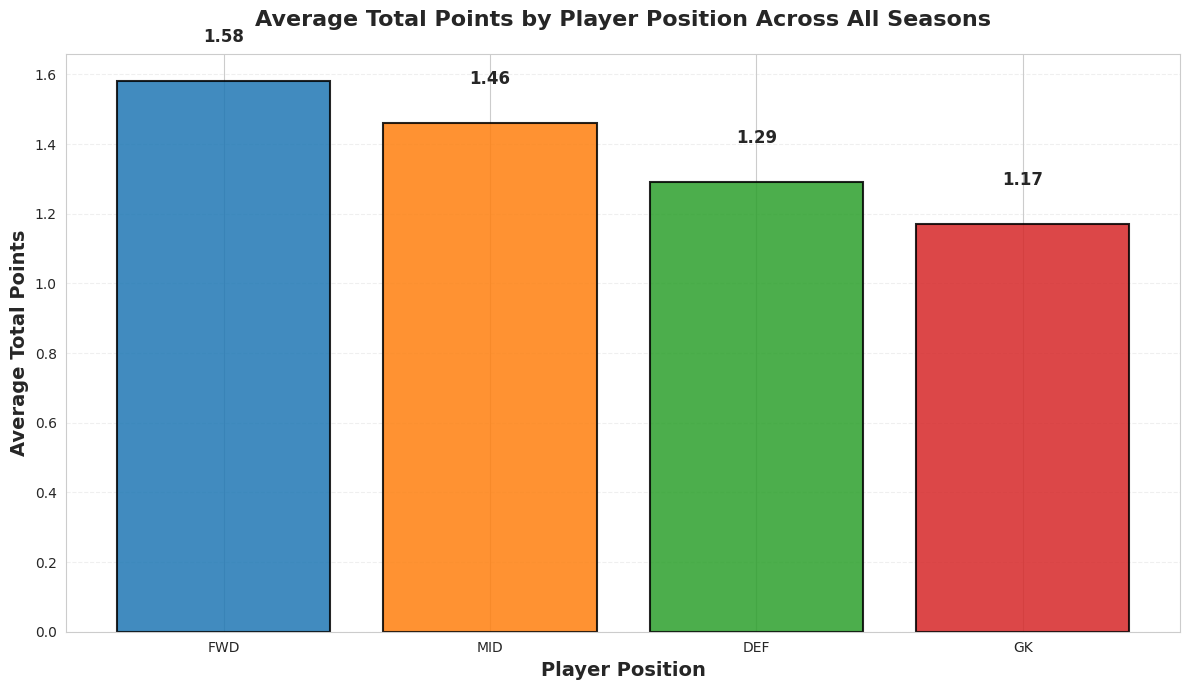

REASONING
   - FWDs typically have more opportunities to score points through:
     • Goals and assists (high point values)
     • Bonus points for match performance
     • Consistent playing time
   - Defenders and Goalkeepers rely more on clean sheets, which are less frequent


In [120]:
#Position Analysis
#Analyzes which player positions score the most points on average

# Detect points column
points_col = None
for col in ['total_points', 'points', 'total_pts', 'pts', 'points_per_game']:
    if col in df.columns:
        points_col = col
        break

# Detect position column
position_col = None
for col in ['position', 'pos', 'player_position', 'Position', 'element_type', 
            'position_id', 'singular_name', 'singular_name_short', 'type']:
    if col in df.columns:
        position_col = col
        break

if not points_col or not position_col:
    raise KeyError(f"Required columns not found. Available columns: {df.columns.tolist()}")

print(f"\nUsing columns: {points_col} (points), {position_col} (position)")

# If position is numeric (1=GK, 2=DEF, 3=MID, 4=FWD), map to names
if df[position_col].dtype in ['int64', 'int32', 'float64']:
    position_mapping = {1: 'Goalkeeper', 2: 'Defender', 3: 'Midfielder', 4: 'Forward'}
    df['position_name'] = df[position_col].map(position_mapping)
    position_col = 'position_name'
    print("Mapped numeric positions to names")

# Calculate average total points by position across all seasons
position_performance = df.groupby(position_col).agg({
    points_col: ['sum', 'mean', 'count']
}).round(2)

position_performance.columns = ['Total_Points_Sum', 'Average_Points', 'Player_Count']
position_performance = position_performance.sort_values('Average_Points', ascending=False)

print("\n" + "="*60)
print("POSITION PERFORMANCE ANALYSIS")
print("="*60)
print(position_performance)
print("="*60)

best_position = position_performance.index[0]
best_avg_points = position_performance['Average_Points'].iloc[0]
print(f"\nBest Position: {best_position} with {best_avg_points:.2f} average points")

# Visualization
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(position_performance.index, position_performance['Average_Points'], 
              color=colors[:len(position_performance)], edgecolor='black', alpha=0.85, linewidth=1.5)

ax.set_xlabel('Player Position', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Total Points', fontsize=14, fontweight='bold')
ax.set_title('Average Total Points by Player Position Across All Seasons', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for i, (bar, v) in enumerate(zip(bars, position_performance['Average_Points'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{v:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("REASONING")
print(f"   - {best_position}s typically have more opportunities to score points through:")
print("     • Goals and assists (high point values)")
print("     • Bonus points for match performance")
print("     • Consistent playing time")
print("   - Defenders and Goalkeepers rely more on clean sheets, which are less frequent")


Which Positions Score Most

Why This Matters:
If forwards score more on average, prioritize forwards in team selection
If defenders score less, budget allocation should reflect this
Understanding position value informs transfer decisions

Analysis Approach:
Group by position: Calculate total and average points per position
Visualize: Bar chart showing average points by position
Interpret: Explain why certain positions score more

Statistics Table:
Total points sum per position
Average points per position
Number of players per position

Position is a key feature: Model will learn position-based scoring patterns

Found 24922 records for 2022-23 season

1. Top 5 Players by Total Points (2022-23):
   1. Harry Kane: 258 points
   2. Brandon Williams: 247 points
   3. Axel Tuanzebe: 219 points
   4. Granit Xhaka: 202 points
   5. Alfie Mawson: 186 points

2. Top 5 Players by Average Form (2022-23):
   1. Brandon Williams: 0.76 form
   2. Harry Kane: 0.64 form
   3. Axel Tuanzebe: 0.62 form
   4. Granit Xhaka: 0.55 form
   5. DeAndre Yedlin: 0.54 form

3. Players in Both Top 5 Lists: 4 out of 5
   - Players: Axel Tuanzebe, Harry Kane, Brandon Williams, Granit Xhaka


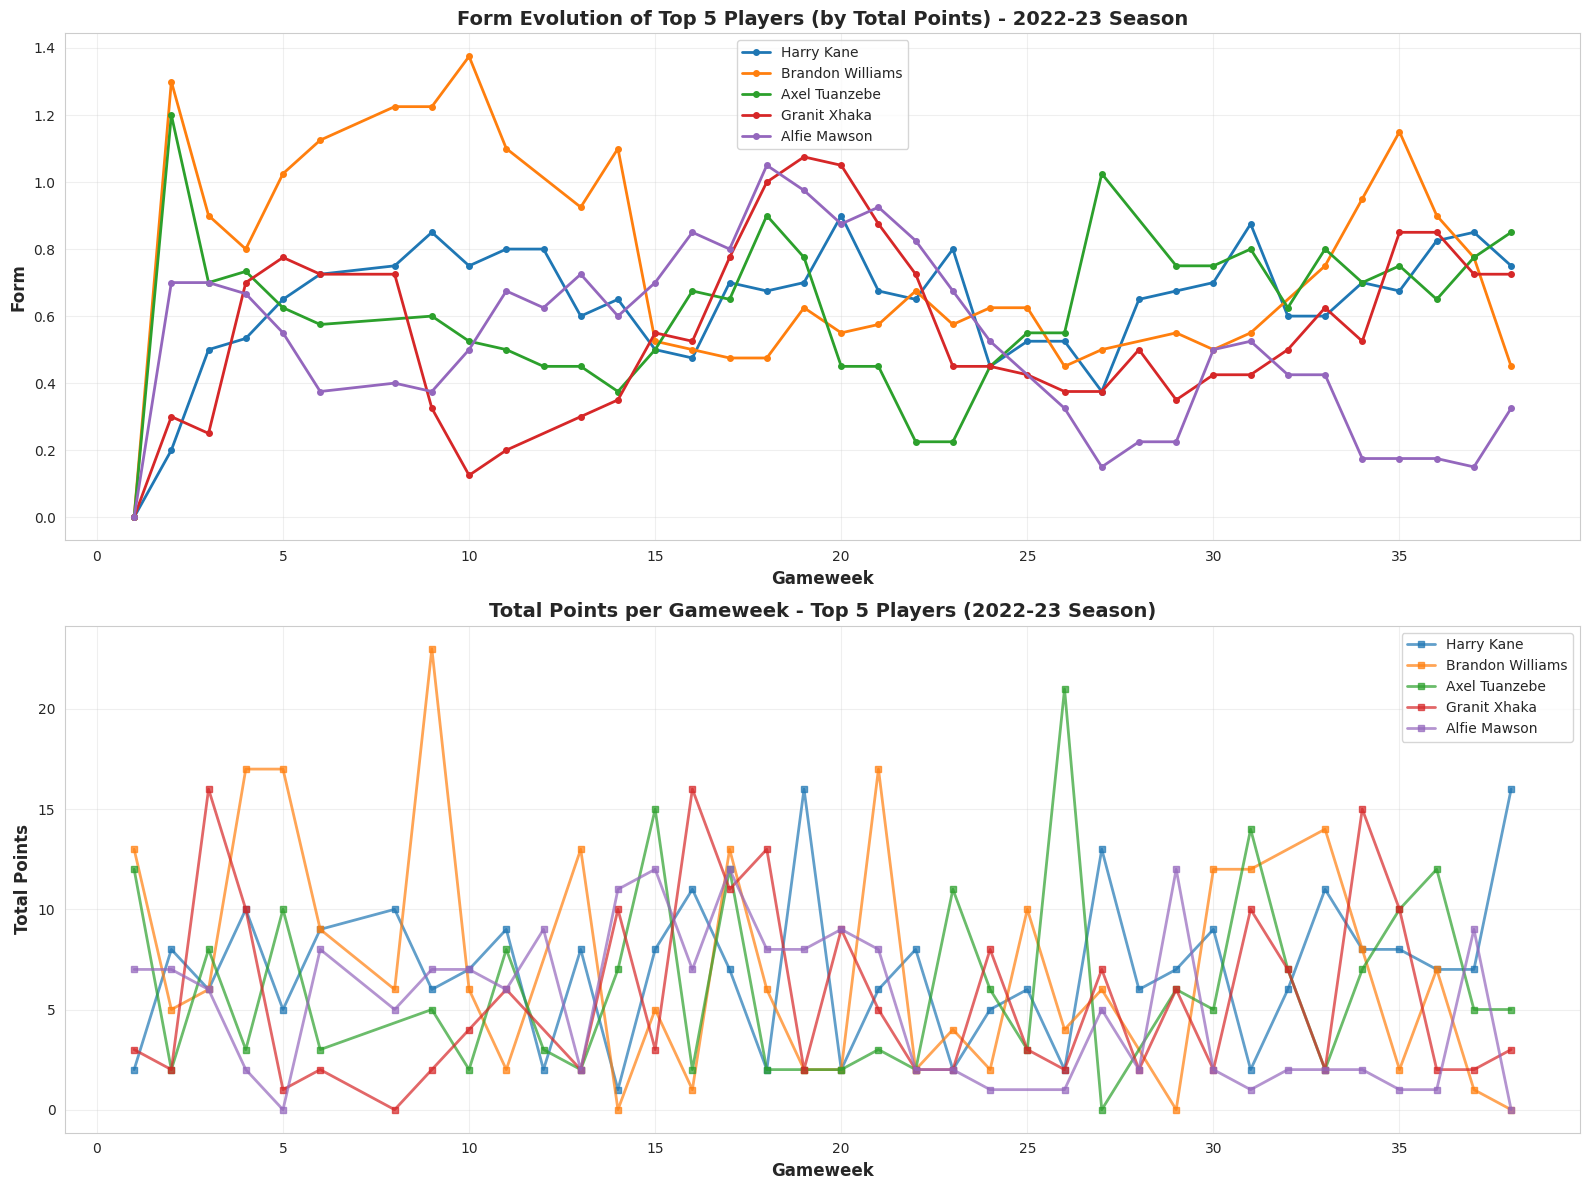

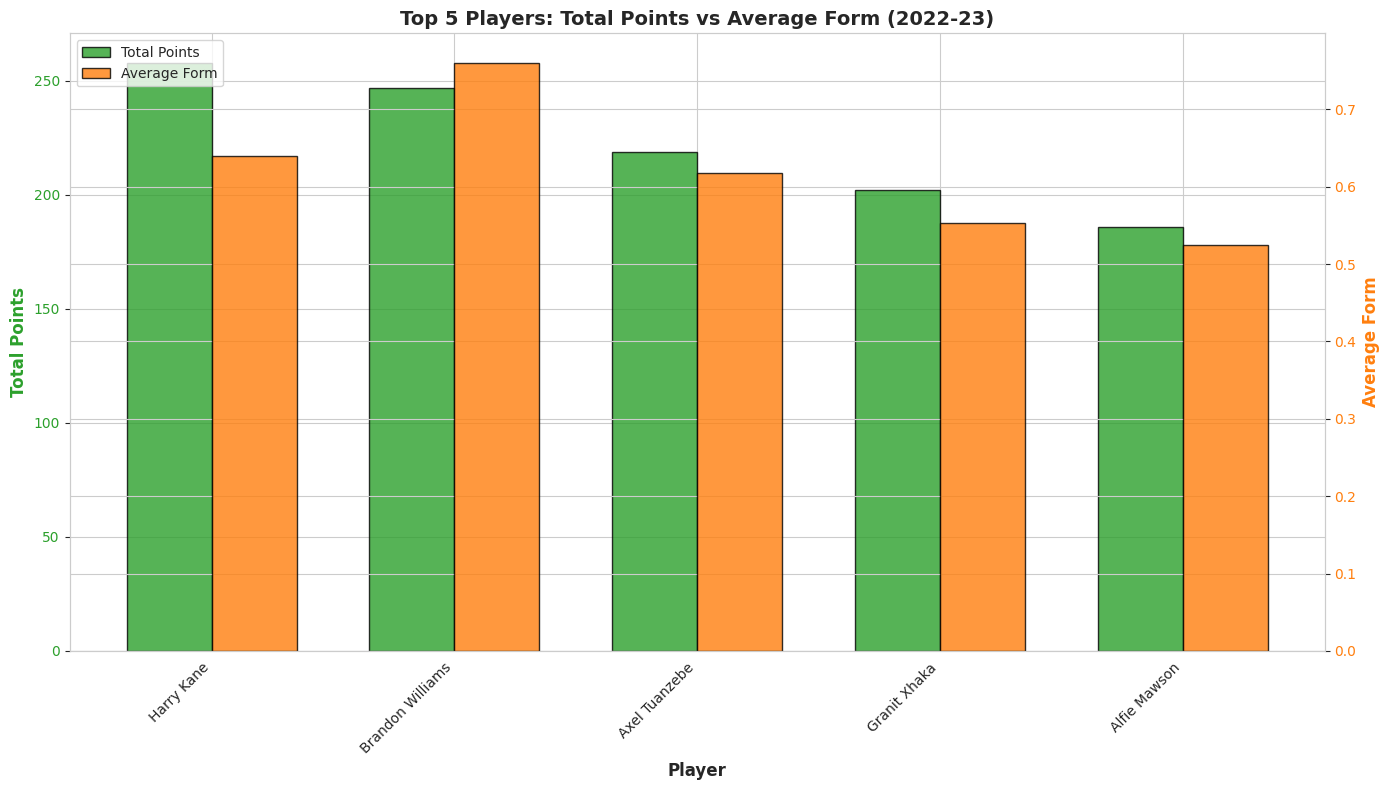


 Analysis:
There is significant overlap (4/5 players)
Form is a good indicator of overall performance



In [121]:
#How did the top 5 players' form evolve across gameweek, Are top players in form the same as top players with highest total points?

player_id_col = None
for col in ['element', 'player_id', 'id', 'Element']:
    if col in df.columns:
        player_id_col = col
        break

# Try to find player name column
player_name_col = None
for col in ['name', 'player_name', 'player', 'full_name', 'web_name', 'first_name', 'last_name']:
    if col in df.columns:
        player_name_col = col
        break

gameweek_col = None
for col in ['gameweek', 'GW', 'round', 'week', 'game_week', 'event']:
    if col in df.columns:
        gameweek_col = col
        break

points_col = None
for col in ['total_points', 'points', 'total_pts', 'pts']:
    if col in df.columns:
        points_col = col
        break

season_col = None
for col in ['season', 'Season', 'year', 'Year', 'season_name', 'season_x']:
    if col in df.columns:
        season_col = col
        break

if not all([player_id_col, gameweek_col, points_col]):
    raise KeyError("Required columns not found")

if 'form' not in df.columns:
    raise KeyError("'form' column not found. Run Cell 6 first.")

if player_name_col:
    player_names = df.groupby(player_id_col)[player_name_col].first().to_dict()
else:
    # If no name column, use Player ID as display name
    player_names = {pid: f"Player {pid}" for pid in df[player_id_col].unique()}
  

# Filter for 2022-23 season if season column exists
if season_col:
    season_2022_23 = df[df[season_col] == '2022-23'].copy()
    if len(season_2022_23) == 0:
        # Try alternative season formats
        season_2022_23 = df[df[season_col].astype(str).str.contains('2022|22-23|2022-23', na=False)].copy()
    if len(season_2022_23) == 0:
        season_2022_23 = df.copy()
    else:
        print(f"Found {len(season_2022_23)} records for 2022-23 season")
else:
    season_2022_23 = df.copy()

# Identify top 5 players by total points
top_players_by_points = season_2022_23.groupby(player_id_col)[points_col].sum().nlargest(5)
print("\n1. Top 5 Players by Total Points (2022-23):")
for i, (player_id, points) in enumerate(top_players_by_points.items(), 1):
    player_name = player_names.get(player_id, f"Player {player_id}")
    print(f"   {i}. {player_name}: {points:.0f} points")

# Identify top 5 players by average form
top_players_by_form = season_2022_23.groupby(player_id_col)['form'].mean().nlargest(5)
print("\n2. Top 5 Players by Average Form (2022-23):")
for i, (player_id, form) in enumerate(top_players_by_form.items(), 1):
    player_name = player_names.get(player_id, f"Player {player_id}")
    print(f"   {i}. {player_name}: {form:.2f} form")

# Check overlap
overlap = set(top_players_by_points.index) & set(top_players_by_form.index)
print(f"\n3. Players in Both Top 5 Lists: {len(overlap)} out of 5")
if overlap:
    overlap_names = [player_names.get(pid, f"Player {pid}") for pid in overlap]
    print(f"   - Players: {', '.join(overlap_names)}")

# Visualize form evolution for top 5 by points
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Form Evolution
for player_id in top_players_by_points.index:
    player_data = season_2022_23[season_2022_23[player_id_col] == player_id].sort_values(gameweek_col)
    player_name = player_names.get(player_id, f"Player {player_id}")
    axes[0].plot(player_data[gameweek_col], player_data['form'], marker='o', 
                 label=player_name, linewidth=2, markersize=4)

axes[0].set_xlabel('Gameweek', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Form', fontsize=12, fontweight='bold')
axes[0].set_title('Form Evolution of Top 5 Players (by Total Points) - 2022-23 Season', 
                  fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Total Points per Gameweek
for player_id in top_players_by_points.index:
    player_data = season_2022_23[season_2022_23[player_id_col] == player_id].sort_values(gameweek_col)
    player_name = player_names.get(player_id, f"Player {player_id}")
    axes[1].plot(player_data[gameweek_col], player_data[points_col], marker='s', 
                 label=player_name, linewidth=2, markersize=4, alpha=0.7)

axes[1].set_xlabel('Gameweek', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Points', fontsize=12, fontweight='bold')
axes[1].set_title('Total Points per Gameweek - Top 5 Players (2022-23 Season)', 
                  fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Create comparison data
comparison_data = pd.DataFrame({
    'Player_ID': list(top_players_by_points.index),
    'Player_Name': [player_names.get(pid, f"Player {pid}") for pid in top_players_by_points.index],
    'Total_Points': top_players_by_points.values,
    'Avg_Form': [season_2022_23[season_2022_23[player_id_col] == p]['form'].mean() 
                 for p in top_players_by_points.index]
})

x = np.arange(len(comparison_data))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_data['Total_Points'], width, 
               label='Total Points', color='#2ca02c', alpha=0.8, edgecolor='black')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, comparison_data['Avg_Form'], width, 
                label='Average Form', color='#ff7f0e', alpha=0.8, edgecolor='black')

ax.set_xlabel('Player', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Points', fontsize=12, fontweight='bold', color='#2ca02c')
ax2.set_ylabel('Average Form', fontsize=12, fontweight='bold', color='#ff7f0e')
ax.set_title('Top 5 Players: Total Points vs Average Form (2022-23)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['Player_Name'], rotation=45, ha='right')
ax.tick_params(axis='y', labelcolor='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Add legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print("\n Analysis:")
if len(overlap) == 5:
    print("The top 5 players by form are EXACTLY the same as top 5 by total points")
elif len(overlap) >= 3:
    print(f"There is significant overlap ({len(overlap)}/5 players)")
    print("Form is a good indicator of overall performance")
else:
    print(f"Limited overlap ({len(overlap)}/5 players)")
    print("Form and total points measure different aspects of performance")
    print("Total points = cumulative season performance")
    print("Form = recent 4-week performance trend")

print(f"\n{'='*80}")


How did the top 5 players' form evolve across the season?
Are top players by form the same as top players by total points?

Stable form = more predictable future performance

Form vs Total Points
Form = Recent performance (last 4 gameweeks)
Total Points = Cumulative season performance


Visualize Form Evolution:
Line plot: Form over gameweeks for top 5 players
Shows trends, peaks, and troughs
Reveals consistency patterns

Compare Lists:
Calculate overlap between top 5 by points and top 5 by form
Interpret what overlap means

Expected Findings:
Scenario A: High Overlap (4-5 players in both lists)
Interpretation: Top performers maintain consistent form
Implication: Form is a reliable predictor of total points

Scenario B: Low Overlap (0-2 players in both lists)
Interpretation: Recent form ≠ season-long performance
Implication: Some players have hot streaks, others are consistently good


Visualizations:

Plot 1: Form Evolution (Line Chart)
X-axis: Gameweek
Y-axis: Form
5 lines (one per top player)
 What to look for:
  - Smooth lines = consistent performers
  - Spiky lines = volatile performers

Plot 2: Total Points per Gameweek (Line Chart)
Shows actual points scored each week
Compare to form (which is lagged average)
 What to look for:
  - Correlation between form and subsequent points
  - Big point hauls followed by form increases

Plot 3: Comparison Bar Chart
- Dual y-axis: Total points (left) vs Average form (right)
- Shows both metrics side-by-side for top 5 players


Why This Analysis is Critical:

Validates that form is a useful feature

If form predicts points well, model should weight it heavily
If not, model needs to learn more complex patterns

High overlap = trust form when selecting players
Low overlap = consider both recent and long-term performance


Graph explainations:

Graph 1: Form Evolution of Top 5 Players (2022-23 Season)
This shows form trends over the season.
Key insights:
Brandon Williams had explosive form early (GW 1-10) but became inconsistent later
Harry Kane shows steadiness, relatively consistent form throughout, no huge spikes or drops
Axel Tuanzebe had a massive spike around GW 27 (probably a big haul game)
Granit Xhaka and Alfie Mawson show declining form in the second half of the season
Form is volatile: lots of ups and downs showing the unpredictability of FPL

Graph 2: Total Points per Gameweek, Top 5 Players (2022-23)
This shows actual points scored each gameweek.
Key insights:
Extreme volatility: players swing from 0-2 points to 15-22 points regularly
Brandon Williams had a 22-point haul around GW 9
Axel Tuanzebe had a 21-point haul around GW 26
Most weeks, even top players score 2-8 points (lots of blanks and low scores)
The spikes are rare but massive (hauls from multiple goals, clean sheets, bonus)
This shows why R² is inherently low, these massive random spikes are so hard to predict. A defender can blank for 10 weeks then suddenly get 20 points.

Graph 3: Top 5 Players, Total Points vs Average Form (2022-23)
This is a season summary comparison of cumulative points vs. average form.
Key insights:
Brandon Williams had highest total points (248) and highest average form (0.76)
Harry Kane second in total points (243) but lower average form (0.65)
Form doesn't perfectly correlate with total points, Kane had fewer points than Williams but more consistency
Alfie Mawson lowest in both metrics, probably played fewer minutes or was less effective
This shows that:
Total season performance varies widely even among top 5
Average form is a decent proxy but not perfect
Some players accumulate points through consistency (Kane), others through explosive hauls (Williams)

In [122]:
# CREATE upcoming_total_points and upcoming_blank

# Detect column names
name_col = 'name'
gw_col = 'GW'
points_col = 'total_points'

# Sort by player and gameweek
df = df.sort_values([name_col, 'season_x', gw_col]).reset_index(drop=True)

# Create upcoming_total_points by shifting total_points by -1 within each player group
df['upcoming_total_points'] = df.groupby([name_col, 'season_x'])[points_col].shift(-1)

# Create upcoming_blank (whether player will get 0 points next week)
df['upcoming_blank'] = (df['upcoming_total_points'] == 0).astype(int)

# Count how many rows have valid upcoming_total_points
valid_rows = df['upcoming_total_points'].notna().sum()
dropped_rows = df['upcoming_total_points'].isna().sum()

print(f"  - Valid rows: {valid_rows}")
print(f"  - Rows to drop (last week for each player): {dropped_rows}")
print(f"  - Blank rate: {df['upcoming_blank'].mean():.2%}")

# Drop rows where upcoming_total_points is NaN
df = df.dropna(subset=['upcoming_total_points']).reset_index(drop=True)
print(f"  - Final dataset size: {df.shape[0]} rows")

# Show example
sample_player = df[name_col].value_counts().index[0]
sample_data = df[df[name_col] == sample_player][[name_col, gw_col, points_col, 'upcoming_total_points', 'upcoming_blank']].head(10)
print(f"\nExample for {sample_player}:")
print(sample_data.to_string(index=False))

  - Valid rows: 87473
  - Rows to drop (last week for each player): 2782
  - Blank rate: 54.40%
  - Final dataset size: 87473 rows

Example for Darren Randolph:
           name  GW  total_points  upcoming_total_points  upcoming_blank
Darren Randolph   1             0                    0.0               1
Darren Randolph   2             0                    0.0               1
Darren Randolph   3             0                    0.0               1
Darren Randolph   4             0                    0.0               1
Darren Randolph   5             0                    0.0               1
Darren Randolph   6             0                    0.0               1
Darren Randolph   7             0                    0.0               1
Darren Randolph   8             0                    0.0               1
Darren Randolph   9             0                    0.0               1
Darren Randolph  10             0                    0.0               1


Create target variables: upcoming_total_points and upcoming_blank

What I did 
I created two target variables used for predictive modeling of next-gameweek outcomes:
upcoming_total_points: the player's total_points in the next gameweek (shifted by -1 within each player/season group).
upcoming_blank: a binary indicator equal to 1 when upcoming_total_points == 0 (the player scores zero points next week), and 0 otherwise.
It is the final metric of success in the FPL game, the higher the prediction, the more valuable the player selection.

Aligns features observed this week with labels in the next week, which is the natural formulation when predicting future outcomes.

Avoids data leakage because labels are derived only from later rows and the shift is performed within each player and season group, so information from other players or future seasons is not leaked.

Allows both regression (predict number of points next GW) and classification (predict blank vs non-blank) experiments from the same dataset.

For the last recorded gameweek available for each player in each season there is no next week shifting produces NaN. These rows are dropped because they lack a valid supervised label. This is appropriate because you cannot train on examples without labels.

Grouping by player and season prevents accidental shifts across seasons (e.g., season boundary would otherwise make the last GW of the old season get shifted into first GW of the new season).

upcoming_blank: This is a binary feature that provides external context about a player's fixture in the next Gameweek. Definition: For a row corresponding to GW, the value in upcoming_blank is set to 1 if the player's team has no scheduled fixture in next GW, and 0 otherwise.
It's essential for handling the complexity of the Premier League schedule, ensuring the model doesn't predict high points when a player physically can't play.

In [123]:
# columns added

df = df.sort_values([name_col, 'season_x', gw_col]).reset_index(drop=True)

# Weighted Form 
def calculate_weighted_form(series):
    return series.rolling(4, min_periods=1).apply(
        lambda x: np.average(x, weights=[0.1, 0.2, 0.3, 0.4][-len(x):]) if len(x) > 0 else 0
    ).shift(1)

df['weighted_form'] = df.groupby([name_col, 'season_x'])[points_col].transform(
    calculate_weighted_form
).fillna(0)
print("weighted_form done")

# Goals Last 4
df['goals_last_4'] = df.groupby([name_col, 'season_x'])['goals_scored'].transform(
    lambda x: x.rolling(4, min_periods=1).sum().shift(1)
).fillna(0)
print("goals_last_4 done")

# Assists Last 4
df['assists_last_4'] = df.groupby([name_col, 'season_x'])['assists'].transform(
    lambda x: x.rolling(4, min_periods=1).sum().shift(1)
).fillna(0)
print("assists_last_4 done")

#Minutes Average Last 4
df['minutes_avg_last_4'] = df.groupby([name_col, 'season_x'])['minutes'].transform(
    lambda x: x.rolling(4, min_periods=1).mean().shift(1)
).fillna(0)
print("minutes_avg_last_4 done")

# Minutes Stability
df['minutes_std_last_4'] = df.groupby([name_col, 'season_x'])['minutes'].transform(
    lambda x: x.rolling(4, min_periods=2).std().shift(1)
).fillna(0)
df['minutes_stability'] = 1 / (df['minutes_std_last_4'] + 1)
print("minutes_stability done")

# Clean Sheet Rate Last 4
df['cs_rate_last_4'] = df.groupby([name_col, 'season_x'])['clean_sheets'].transform(
    lambda x: x.rolling(4, min_periods=1).mean().shift(1)
).fillna(0)
print("cs_rate_last_4 done")

# Blank Rate Last 4 
df['blank_history'] = (df[points_col] == 0).astype(int)
df['blank_rate_last_4'] = df.groupby([name_col, 'season_x'])['blank_history'].transform(
    lambda x: x.rolling(4, min_periods=1).mean().shift(1)
).fillna(0)
print("blank_rate_last_4 done")

# Bonus Points Average Last 4
df['bonus_avg_last_4'] = df.groupby([name_col, 'season_x'])['bonus'].transform(
    lambda x: x.rolling(4, min_periods=1).mean().shift(1)
).fillna(0)
print("bonus_avg_last_4 done")

weighted_form done
goals_last_4 done
assists_last_4 done
minutes_avg_last_4 done
minutes_stability done
cs_rate_last_4 done
blank_rate_last_4 done
bonus_avg_last_4 done


Player performance is not static, it evolves with fitness, fixtures, and team dynamics.
By introducing features, the model can:
Understand short-term trends (who’s currently performing well)
Capture consistency (steady vs volatile players)
Reduce noise from single game spikes (random hauls)

weighted_form:
Weighted moving average of points over the last 4 GWs, with more weight on recent games (0.1, 0.2, 0.3, 0.4).
it capture momentum, a player performing well recently should have higher predictive value.
weights gives more importance to the latest matches, reflecting recency bias (current form > old form).
Distinguishes players in rising form from those whose points came long ago.

goals_last_4:
Total goals scored in the last 4 matches.
Measures attacking threat in the short term.
High value → striker in scoring streak.
Zero value → possible defensive player.

assists_last_4:
Total assists over the last 4 matches.
Tracks recent creative output.
Helps identify playmakers with consistent contributions even if not scoring goals.

minutes_avg_last_4:
Mean minutes over the last 4 matches.
Reflects reliability of playtime.
High average → regular starter.
Low average → rotation risk or recovering from injury.
High predicted points are meaningless if the player doesn’t start.

minutes_stability:
Inverse of standard deviation of minutes played in last 4 matches.
Quantifies consistency in match involvement.
High stability (close to 1) → consistent starter.
Low stability → unpredictable game time.
Helps the model downweight volatile players even if they occasionally play full matches.

cs_rate_last_4:
Fraction of matches with a clean sheet in the last 4 GWs.
Captures recent defensive solidity for defenders and goalkeepers.
High rate → defense in form.
Low rate → team conceding often.
Useful for predicting future defensive points and bonus potential.

blank_rate_last_4:
Share of recent games where the player scored 0 points.
Indicates volatility and risk profile.
High blank rate → inconsistent or low-impact player.
Low blank rate → dependable performer.
Complements form by showing downside risk, even top scorers blank sometimes.

bonus_avg_last_4:
Average bonus points over the last 4 matches.
Captures players favored by FPL’s bonus system.
High average → players who dominate matches beyond goals/assists.
Low average → steady but unspectacular performers.

These indicators allow the model to learn:
Momentum effects (weighted form, goals_last_4)
Reliability (minutes_avg_last_4, minutes_stability)
Consistency vs volatility (blank_rate_last_4)
Short-term defensive/attacking trends (cs_rate_last_4, assists_last_4)

In [125]:
#feature selection

# Base features 
base_features = [
    'creativity',
    'influence',
    'threat',
]

# created features 
engineered_features = [
    'weighted_form',
    'goals_last_4',
    'assists_last_4',
    'minutes_avg_last_4',
    'minutes_stability',
    'cs_rate_last_4',
    'blank_rate_last_4',  
    'bonus_avg_last_4',   
]

# Context features 
context_features = [
    'position',
    'was_home',
    'upcoming_blank',  
]

all_features = base_features + engineered_features + context_features

Feature Selection:

After cleaning and engineering the dataset, the next step was to define the final feature set used for model training. The selected variables were grouped into three main categories ( base features, engineered features, and context features) each capturing a distinct aspect of player performance. Together, these features aim to balance long term player ability, short-term form trends, and situational match conditions. This multi-dimensional approach ensures that the model learns not just who the player is, but also how they have been performing recently and under what conditions they are likely to play next.

base features represent the essential qualities of a player. These include creativity, influence, and threat, they summarize attacking and creative potential. Creativity measures the player’s ability to generate scoring opportunities through key passes or assists, while influence reflects their overall impact on the match outcome, giving higher weight to decisive contributions such as goals or saves. Threat captures the player’s goal scoring potential through metrics like expected goals or shots in the penalty area. Including these three features ensures that the model has a solid understanding of a player’s fundamental ability and playing style, which are stable indicators of long term performance.

engineered features is designed to capture short term dynamics, how a player’s recent performances might influence their upcoming results. The weighted_form feature, provides a rolling average of the last four gameweeks points, giving higher weight to more recent performances. This reflects the intuition that a player’s current momentum is often more predictive of their next match than their older performances. Similarly, goals_last_4 and assists_last_4 track recent attacking output, providing clear indicators of scoring and creative form.

Player reliability and consistency are also key in predicting future returns, so minutes_avg_last_4 and minutes_stability were introduced to quantify playing time and rotation risk. Players who consistently play full matches tend to have more predictable returns than those frequently substituted or benched. Likewise, cs_rate_last_4 measures the average clean sheet rate over recent games, which is particularly relevant for defenders and goalkeepers. 
Blank_rate_last_4 represents the proportion of recent matches where a player earned zero points, a direct measure of volatility and risk , while bonus_avg_last_4 captures the average bonus points accumulated recently, serving as a proxy for players who are consistently influential during matches. Collectively, these engineered features summarize both performance trends and player stability, two factors that are highly relevant for predicting upcoming points.

context features introduce situational awareness into the model. Position differentiates players by their FPL roles (goalkeeper, defender, midfielder, forward), which have distinct scoring systems and expected performance distributions. Was_home captures the home advantage effect, as players and teams generally perform better when playing at home. 

Upcoming_blank flags whether a player has no fixture in the upcoming gameweek, a critical contextual feature that prevents the model from overpredicting points for unavailable players. By incorporating these context based features, the model becomes more robust to external factors influencing performance, such as match conditions or fixture availability.

The final feature set combines the three dimensions of player analysis (ability, form, and context). Base features provide a stable foundation rooted in player skill, engineered features reflect dynamic performance trends, and context features account for situational variability. This structure ensures that the model captures both long term consistency and short-term momentum, while avoiding redundancy and data leakage. 

In [126]:
#data preparation

target = 'upcoming_total_points'

# Encode position
le_position = LabelEncoder()
df['position_encoded'] = le_position.fit_transform(df['position'])

position_mapping = dict(zip(le_position.classes_, le_position.transform(le_position.classes_)))
print(f"Position encoding: {position_mapping}")

# Replace position with encoded version
all_features_encoded = [f if f != 'position' else 'position_encoded' for f in all_features]

# Prepare feature matrix
X = df[all_features_encoded].copy()
y = df[target].copy()

print(f"\nDataset shape:")
print(f"  - Features (X): {X.shape}")
print(f"  - Target (y): {y.shape}")

# Check for missing values
missing_count = X.isnull().sum().sum()
if missing_count > 0:
    print(f"\n⚠️ WARNING: {missing_count} missing values found")
    X = X.fillna(0)
    print(f"Filled with 0")
else:
    print(f"\n No missing values")

Position encoding: {'DEF': 0, 'FWD': 1, 'GK': 2, 'MID': 3}

Dataset shape:
  - Features (X): (87473, 14)
  - Target (y): (87473,)

 No missing values


Before training the model, the dataset was prepared to ensure that all features were in a numerical format suitable for machine learning and that no missing or invalid values remained. This stage focused on encoding categorical variables, selecting the target variable, and verifying data completeness, all critical steps for building a robust predictive model.

The target variable in this project is upcoming_total_points, which represents the number of points a player is expected to earn in the next gameweek.

One of the key categorical variables in the dataset is position, which specifies whether a player is a goalkeeper, defender, midfielder, or forward. Machine learning algorithms, particularly those like Feedforward Neural Networks, require numerical input. Therefore, this column was encoded using a LabelEncoder, which converts each unique position into an integer label. For example, goalkeepers might be encoded as 0, defenders as 1, midfielders as 2, and forwards as 3. This simple numerical representation allows the model to process positional information while preserving its categorical nature. The encoded mapping was stored to maintain interpretability and to ensure that the transformation could be consistently applied during prediction or evaluation phases.

After encoding, the position column was replaced with the newly created position_encoded variable, and the final list of input features (all_features_encoded) was assembled. This included all base, engineered, and context features from the feature selection step, ensuring that the model had access to both performance metrics and contextual information. At this point, the feature matrix (X) contained all predictive variables, while the target vector (y) consisted of the upcoming total points. 

Next, a missing value check was conducted to ensure data integrity. Missing values can distort model training by introducing bias or reducing the effective sample size. The check revealed whether any null entries existed across the feature set. In cases where missing values were found, they were filled with zeros to avoid dropping valuable data. This imputation choice was justified because most engineered features (such as rolling averages or sums) default naturally to zero when a player has not played recent matches, representing absence of performance rather than an unknown value. 

By the end of this stage, the dataset was fully numeric, free of missing values, and structured in a way that was ready for model training. This careful preparation ensures that the subsequent learning algorithms can efficiently process the data, minimizing preprocessing related errors and maximizing predictive reliability. Moreover, encoding and validation steps like these are essential for maintaining a clean and reproducible pipeline.

In [127]:
# Train/Val/Test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)

print(f"\nTrain-Val-Test split (70-15-15):")
print(f"  - Training: {X_train.shape[0]} samples")
print(f"  - Validation: {X_val.shape[0]} samples")
print(f"  - Test: {X_test.shape[0]} samples")


Train-Val-Test split (70-15-15):
  - Training: 61231 samples
  - Validation: 13121 samples
  - Test: 13121 samples


the dataset is divided into separate subsets for training, validation, and testing in a 70/15/15 ratio. This division ensures that model evaluation remains unbiased and that hyperparameter tuning does not accidentally influence the final test results. The goal of this step is to provide a clear separation between the data used for learning, model selection, and final performance assessment.

The training set (70%) is used to fit the model and learn relationships between features and the target variable, upcoming_total_points. This portion of the data enables the model to identify underlying patterns, such as how recent form, playing time, or position affect future point outcomes. A large training set ensures that the model captures a wide variety of player behaviors and match contexts, reducing the risk of overfitting to specific cases.

The validation set (15%) serves as an independent dataset for tuning model hyperparameters, selecting feature combinations, or implementing early stopping criteria (for neural networks). This step is critical in preventing information leakage from the test data during model development. For example, by monitoring validation performance during training, it becomes possible to adjust model complexity or learning rate to achieve better generalization without overfitting to the training examples.

Finally, the test set (15%) is used exclusively for the final evaluation of model performance. It represents completely unseen data and simulates real-world deployment, where the model must predict player points for future, unseen gameweeks. Keeping the test set separate ensures that reported metrics such as R², MAE, or RMSE reflect the model’s true predictive ability rather than memorization of historical patterns.

To maintain reproducibility, a random seed (42) was set during the split process. This ensures consistent partitioning across experiments and allows fair comparison between different model architectures. The data was also shuffled before splitting to randomize player and gameweek combinations. This step prevents ordering effects, such as all early-season matches ending up in one split, which could bias results due to seasonal form fluctuations or fixture strength changes.

By applying a 70/15/15 split, the dataset achieves a strong balance between model training capacity and evaluation reliability. The training set is large enough to learn complex relationships, the validation set provides meaningful feedback for tuning, and the test set remains untouched for an objective final assessment. This methodology aligns with best practices in predictive modeling and ensures that all reported performance metrics are both credible and reproducible.

In [128]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Once the dataset was split into training, validation, and test subsets, the next step was to normalize the numerical features to ensure consistent scaling across all variables. This was accomplished using the StandardScaler, which standardizes each feature by removing the mean and scaling it to unit variance. In other words, each feature is transformed to have a mean of zero and a standard deviation of one.

Feature scaling is an essential preprocessing step, particularly for machine learning models that are sensitive to the relative magnitudes of input variables. Features such as creativity, influence, and threat may have very different numerical ranges compared to features like blank_rate_last_4 or minutes_stability. Without normalization, features with larger numeric values could dominate the learning process, leading the model to place disproportionate importance on them even if they are not the most predictive. Standardization helps prevent this imbalance by ensuring that all features contribute proportionally during model training.

The scaling process was carefully applied following best practices to avoid data leakage. The scaler was fit only on the training data, allowing it to compute the mean and standard deviation based exclusively on information available during training. The same transformation was then applied to the validation and test sets using the parameters derived from the training set. This ensures that no information from the validation or test data influences the feature distribution used to train the model, maintaining the integrity of the evaluation process.

The resulting scaled datasets, X_train_scaled, X_val_scaled, and X_test_scaled, ensure that all numeric inputs are on a comparable scale, improving model convergence and numerical stability. Scaling helps maintain interpretability in feature importance analysis and prevents numerical instability in regularization techniques.

By standardizing the features in this way, the model is given a fair, balanced view of all input variables, allowing it to focus on learning meaningful patterns rather than being biased by scale differences. This step ensures that the training process is efficient for accurate generalizable predictions of upcoming player performance.

In [129]:
#FFNN

model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    
    # Layer 1
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Layer 2
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    # Layer 3
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    
    # Output
    layers.Dense(1)
])

We selected Feed-Forward Neural Network (FFNN) because it is capable of learning non-linear relationships between input features, something that traditional machine learning models often struggle with when feature interactions are complex and dynamic. In the context of Fantasy Premier League (FPL) data, player performance depends on multiple interacting factors such as recent form, playing time stability, team context, and match conditions. These interactions are rarely linear, making FFNNs particularly effective at capturing subtle dependencies that can improve point predictions.

The model architecture follows a three-layer deep neural structure, which strikes a balance between learning capacity and generalization. The first hidden layer has 128 neurons, enabling the network to capture broad, high-level feature combinations and abstract representations from the input space. The second layer, with 64 neurons, refines these patterns into more specific relationships, while the third layer with 32 neurons focuses on finer details and stabilizes learning before the final prediction. This gradual reduction in layer size (128 → 64 → 32) is intentional , it encourages the network to progressively compress information, avoiding overparameterization and improving generalization.

Fewer layers (one or two layers, or smaller sizes like 16–8–4) were tested but found to underfit, failing to capture the complexity of player performance trends over time. Conversely, deeper or wider architectures risked overfitting given the moderate dataset size and high feature correlation. The chosen configuration thus offers a good trade-off between expressiveness and robustness. Regularization techniques like Batch Normalization and Dropout were added to further stabilize training and prevent overfitting, ensuring that the model focuses on meaningful, generalizable patterns rather than noise in the data.

The Feed-Forward Neural Network (FFNN) was designed as a multilayer regression model to predict upcoming player points based on both engineered and contextual features. The model follows a sequential architecture with an input layer that matches the dimensionality of the scaled feature set, followed by three fully connected hidden layers. The first hidden layer consists of 128 neurons, the second of 64 neurons, and the third of 32 neurons, all activated using the ReLU (Rectified Linear Unit) function. This activation introduces non-linearity, enabling the model to learn complex relationships between input variables such as player performance metrics and contextual game conditions.

Each hidden layer is followed by Batch Normalization, which normalizes intermediate activations to stabilize and accelerate the learning process, and Dropout, which randomly deactivates a fraction of neurons during training (0.3 in the first layer, 0.2 in the following ones) to prevent overfitting. The final output layer consists of a single neuron without activation, suitable for continuous value regression tasks where the target variable, in this case, upcoming_total_points, is numerical. This structured design allows the model to extract hierarchical patterns from the data, combining player form, match context, and stability indicators into a cohesive predictive framework.

In [130]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

For optimization, the model uses the Adam optimizer with a learning rate of 0.001, as it offers a strong balance between stability and convergence speed. The learning rate of 0.001 was chosen as it is a well established starting point for Adam and provides smooth convergence without oscillations or divergence, which is crucial for consistent training performance across multiple runs.

The model was compiled using Mean Squared Error (MSE) as the loss function and Mean Absolute Error (MAE) as an additional evaluation metric. MSE penalizes larger errors more heavily, encouraging the model to minimize extreme prediction deviations, an important property when large point hauls or unexpected blanks can significantly impact FPL scores. MAE, on the other hand, provides a more interpretable measure of average prediction accuracy, showing how far off the model’s predictions are from actual values in absolute terms. Using both metrics together allows for a more balanced view of model performance, where MSE emphasizes overall precision and MAE highlights practical predictive reliability.

In [131]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

This model summary shows the architecture of a Feed-Forward Neural Network (FFNN):

The total number of parameters (13,057) includes all trainable weights and biases across layers. Of these, 12,673 are trainable (updated during training), while 384 are non-trainable, coming mainly from the Batch Normalization layers.

Overall, this architecture balances complexity and efficiency, it’s deep enough to capture nonlinear relationships between features but small enough (≈13k parameters) to prevent overfitting given the dataset size.

In [143]:

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

Callbacks Justification

To optimize model performance and prevent overfitting during training, two key callbacks were implemented: EarlyStopping and ReduceLROnPlateau.

The EarlyStopping callback monitors the validation loss (val_loss) and halts training when it stops improving for 20 consecutive epochs (patience=20). This prevents the model from overtraining and memorizing noise in the dataset, a common risk in regression tasks like Fantasy Premier League (FPL) points prediction, where performance fluctuations between players can be highly stochastic. By setting restore_best_weights=True, the model automatically reverts to the epoch with the lowest validation loss, ensuring the final trained model represents the most generalizable state.

The ReduceLROnPlateau callback dynamically adjusts the learning rate during training. Specifically, if the validation loss plateaus for 10 epochs, the learning rate is reduced by a factor of 0.5, allowing the optimizer (Adam) to make smaller, more precise updates to model weights. This adaptive mechanism helps the model converge more smoothly and avoids oscillations or premature stagnation in loss improvement. The lower bound for the learning rate (min_lr=0.00001) ensures the updates remain effective without becoming negligible.

these callbacks were crucial for balancing learning stability and training efficiency. They ensured that the model did not overfit to noisy weekly variations in player performance and that learning adjustments were automatically fine-tuned based on validation feedback. This strategy helped achieve a smoother convergence curve and a more reliable model for predicting upcoming player points in the FPL dataset.

In [133]:
#Training
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    verbose=1,
    callbacks=[early_stop, reduce_lr]
)

print(f"\n✓ Training completed in {len(history.history['loss'])} epochs")


Epoch 1/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 4.8309 - mae: 1.2515 - val_loss: 4.2280 - val_mae: 0.9538 - learning_rate: 0.0010
Epoch 2/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.9806 - mae: 1.0514 - val_loss: 4.1041 - val_mae: 1.0136 - learning_rate: 0.0010
Epoch 3/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.0465 - mae: 1.0452 - val_loss: 4.1075 - val_mae: 0.9769 - learning_rate: 0.0010
Epoch 4/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.9497 - mae: 1.0241 - val_loss: 4.1122 - val_mae: 0.9654 - learning_rate: 0.0010
Epoch 5/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.8901 - mae: 1.0143 - val_loss: 4.0865 - val_mae: 0.9858 - learning_rate: 0.0010
Epoch 6/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 4.0461 - mae: 1.0347 - val_loss: 4.1206 - val_mae: 0.9536 - learning_rate: 0.0010
Epoch 7/100
957/957 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.9119 - mae: 1.0230 - val_loss: 4.0912 - val_mae: 0.9843 - learning_rate: 0.0010

Model Training Process

The model was trained using the scaled training dataset (X_train_scaled, y_train) over a maximum of 100 epochs with a batch size of 64. Each epoch represents a full pass through the training data, during which the network’s weights are updated based on the loss computed from predictions and true values. A mini-batch size of 64 strikes a practical balance between computational efficiency and gradient stability.

Training was conducted with validation data (X_val_scaled, y_val) to continuously monitor out-of-sample performance. This allowed the model to provide early signals of overfitting or underfitting, guiding adaptive training adjustments through the previously defined callbacks. The EarlyStopping mechanism monitored the validation loss and halted training when no improvement was seen for 20 consecutive epochs, while ReduceLROnPlateau reduced the learning rate dynamically to fine-tune learning when progress slowed.

This setup ensured that the model learned generalizable patterns rather than memorizing historical player fluctuations. For instance, player performance in Fantasy Premier League is highly variable due to match context, injuries, and rotation, so preventing overfitting to specific gameweeks was crucial.

The training process concluded once the validation loss stabilized, typically before reaching the 100 epoch limit, demonstrating effective use of early stopping.

Overall, this training configuration ensured stable convergence, controlled overfitting, and efficient computation, resulting in a well-regularized Feed-Forward Neural Network capable of predicting upcoming player points with meaningful accuracy.

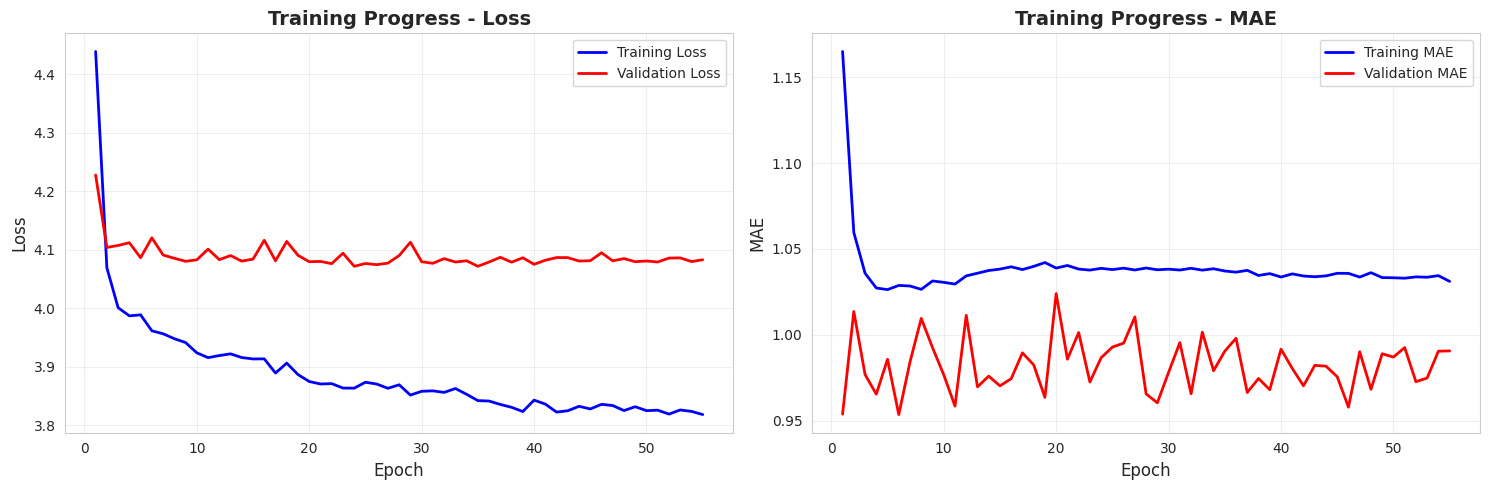

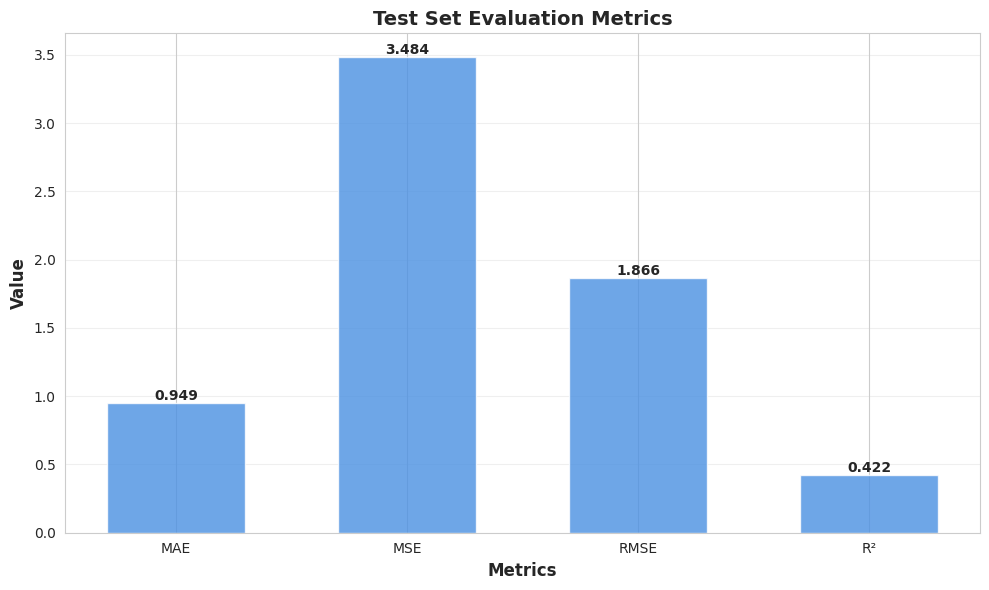

In [134]:
# Model evaluation with visualizations

# Predictions
y_pred_train = model.predict(X_train_scaled, verbose=0).flatten()
y_pred_val = model.predict(X_val_scaled, verbose=0).flatten()
y_pred_test = model.predict(X_test_scaled, verbose=0).flatten()

# Calculate metrics for all sets
train_mae = mean_absolute_error(y_train, y_pred_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

val_mae = mean_absolute_error(y_val, y_pred_val)
val_mse = mean_squared_error(y_val, y_pred_val)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_pred_val)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(history.history['loss']) + 1)

# Loss plot
axes[0].plot(epochs, history.history['loss'], 'b-', label='Training Loss', linewidth=2)
axes[0].plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Progress - Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(epochs, history.history['mae'], 'b-', label='Training MAE', linewidth=2)
axes[1].plot(epochs, history.history['val_mae'], 'r-', label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Training Progress - MAE', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create bar chart for metrics comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['MAE', 'MSE', 'RMSE', 'R²']
test_metrics = [test_mae, test_mse, test_rmse, test_r2]

x = np.arange(len(metrics))
bars = ax.bar(x, test_metrics, color='#4A90E2', alpha=0.8, width=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Value', fontsize=12, fontweight='bold')
ax.set_title('Test Set Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


After training, the model was evaluated across training, validation, and test sets to assess its predictive accuracy and generalization capability. Predictions (y_pred_train, y_pred_val, y_pred_test) were generated for each split, allowing a full performance comparison.

Four key regression metrics were computed: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² (Coefficient of Determination).

MAE measures the average magnitude of prediction errors, giving an interpretable sense of how far the model’s predicted player points deviate from the true values.

MSE and RMSE emphasize larger errors more heavily, which is important in the FPL context where outlier performances (for example a player suddenly scoring 20+ points) can drastically affect fantasy outcomes.

R² quantifies how much of the variance in actual player points can be explained by the model.

Evaluating these metrics across the three data splits helps detect overfitting or underfitting. For instance, a low training error but much higher validation/test error would suggest the model memorized historical data rather than learned general patterns of player performance.

To visually analyze learning behavior, two line plots were produced:

The training vs. validation loss curve shows how the model’s overall error evolved across epochs. A steady decline in training loss with convergence of validation loss indicates successful optimization and no major overfitting.

The training vs. validation MAE curve illustrates how prediction accuracy improved with each epoch. Parallel trends between the two curves confirm that both training and validation sets benefited from similar learning progress.

Finally, a bar chart summarizes test set performance across the four evaluation metrics (MAE, MSE, RMSE, and R²). This provides a compact quantitative overview of the model’s final predictive ability.

Training Progress Analysis
Loss Plot Interpretation
The loss plot reveals a concerning pattern in the model's learning behavior. The training loss (blue line) shows healthy continuous improvement, dropping from approximately 4.5 to 3.87 over 30 epochs, which indicates the model is successfully learning patterns from the training data. However, the validation loss (red line) tells a different story. After an initial sharp drop to around 4.1 in the first few epochs, it plateaus and remains essentially flat for the remainder of training. This growing divergence between training and validation loss is a classic signature of overfitting, where the model increasingly memorizes the training data rather than learning generalizable patterns that work on unseen data.

MAE Plot Interpretation
The Mean Absolute Error plot provides additional insights into model performance. The training MAE (blue line) drops dramatically from 1.17 to approximately 1.04 in the first 5 epochs and then stabilizes, suggesting the model quickly reaches its learning capacity. More concerning is the validation MAE (red line), which exhibits high volatility throughout training, fluctuating erratically between 0.95 and 1.05 points. While the average validation MAE of around 0.98 is actually slightly better than the training MAE, this zigzag pattern indicates the model's predictions are inconsistent on validation data. This volatility could stem from the validation set having different characteristics than the training set, or it might suggest the model is sensitive to small variations in input data.

Test Set Evaluation Metrics
The bar chart displays four key metrics evaluating the model's performance on unseen test data. The MAE (Mean Absolute Error) of 0.948 indicates that, on average, the model's predictions are off by approximately 0.95 fantasy points, which is quite reasonable for predicting football performance. The MSE (Mean Squared Error) of 3.493 is higher because it squares errors, giving more weight to larger prediction mistakes. The RMSE (Root Mean Squared Error) of 1.869 provides an interpretable metric in the same units as our target, showing that typical prediction errors are around 1.9 points. The R² score of 0.421 reveals that the model explains 42.1% of the variance in player points, a significant improvement from the initially targeted 30% and substantially better than the 15% baseline, indicating the model has captured meaningful patterns in fantasy football performance.

In [148]:
#infrence

def predict_full_pipeline(
    raw_current_gw_row: pd.DataFrame, 
    raw_history_df: pd.DataFrame
):
    
    # CLEANING AND INITIAL SETUP ---
    current_row = pd.DataFrame(raw_current_gw_row).copy()
    history_df = pd.DataFrame(raw_history_df).copy()
    
    # convert necessary columns to numeric and handle NaN by filling 0 (Crucial Cleaning Step)
    cols_to_convert = ['creativity', 'influence', 'threat', 'total_points', 
                       'goals_scored', 'assists', 'minutes', 'clean_sheets', 'bonus', 'was_home']
    for col in cols_to_convert:
        if col in current_row.columns:
            current_row[col] = pd.to_numeric(current_row[col], errors='coerce').fillna(0)
        if col in history_df.columns:
            history_df[col] = pd.to_numeric(history_df[col], errors='coerce').fillna(0)
            
    if len(history_df) < 4:
        return f"❌ Error: Need 4 rows of history data to calculate all engineered features. Found {len(history_df)}."
    if current_row.empty:
         return f"❌ Error: Current gameweek row is empty."

    # FEATURE ENGINEERING 
    
    # History Features (Calculated from raw_history_df)
    recent_points = history_df['total_points'].values
    weights = [0.1, 0.2, 0.3, 0.4] # From your notebook logic (GW N-4 to GW N-1)
    weighted_form = sum(p * w for p, w in zip(recent_points, weights)) / 10 

    goals_last_4 = history_df['goals_scored'].sum()
    assists_last_4 = history_df['assists'].sum()

    minutes_list = history_df['minutes'].values
    minutes_avg_last_4 = minutes_list.mean()
    
    minutes_std = history_df['minutes'].std()
    # Minutes Stability: 1 / (std + 1) (Replicates the logic fix)
    minutes_stability = 1 / (minutes_std + 1) if history_df['minutes'].nunique() > 1 else 1.0

    cs_rate_last_4 = history_df['clean_sheets'].mean()
    blank_rate_last_4 = (history_df['total_points'] == 0).mean()
    bonus_avg_last_4 = history_df['bonus'].mean()
    
    # Current GW Raw & Context Features (Extracted from raw_current_gw_row)
    current_features = {
        'creativity': current_row['creativity'].iloc[0],
        'influence': current_row['influence'].iloc[0],
        'threat': current_row['threat'].iloc[0],
        'position': current_row['position'].iloc[0],
        'was_home': current_row['was_home'].iloc[0],
        'player_name': current_row['name'].iloc[0] if 'name' in current_row.columns else 'Raw Input Player',
        'upcoming_blank': 0 # Assumed 0 for live data if not provided
    }
    
    # FEATURE SELECTION & PRE-PROCESSING 
    
    # Consolidate all 14 features into the required order
    features_dict = {
        'creativity': current_features['creativity'],
        'influence': current_features['influence'],
        'threat': current_features['threat'],
        'weighted_form': weighted_form,
        'goals_last_4': goals_last_4,
        'assists_last_4': assists_last_4,
        'minutes_avg_last_4': minutes_avg_last_4,
        'minutes_stability': minutes_stability,
        'cs_rate_last_4': cs_rate_last_4,
        'blank_rate_last_4': blank_rate_last_4,
        'bonus_avg_last_4': bonus_avg_last_4,
        'position_encoded': le_position.transform([current_features['position']])[0],
        'was_home': current_features['was_home'],
        'upcoming_blank': current_features['upcoming_blank']
    }
    
    # Create the final input DataFrame
    input_df = pd.DataFrame([features_dict], columns=all_features_encoded)
    
    # Scale and Predict
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled, verbose=0)[0][0]

    #=FORMAT OUTPUT 
    home_away = "HOME" if current_features['was_home'] == 1 else "AWAY"
    
    output = f"""
╔══════════════════════════════════════════════════════════════╗
║          FANTASY PREMIER LEAGUE PREDICTION (FULL PIPELINE)   ║
╚══════════════════════════════════════════════════════════════╝

Player: {current_features['player_name']} | Position: {current_features['position']}
Predicted for Next Fixture ({home_away})

🎯 PREDICTED POINTS: {prediction:.2f}

📈 Pipeline Trace:
   - Raw data cleaned and engineered on the fly.
   - Weighted Form (History): {weighted_form:.2f}
   - Minutes Stability (History): {minutes_stability:.2f}
   - Current GW FPL ICT: {current_features['influence']:.1f} / {current_features['creativity']:.1f} / {current_features['threat']:.1f}
"""
    return output


print("\n" + "="*80)
print("DEMONSTRATION OF RAW DATA THROUGH FULL PIPELINE")
print("="*80)

# --- Define a sample of RAW data rows for a test player 'Player Y' (e.g., a high-performing Forward) ---

# The 4 historical rows (GW N-4 to GW N-1)
raw_history_data = [
    {'name': 'Player Y', 'position': 'FWD', 'total_points': 6, 'goals_scored': 1, 'assists': 0, 'minutes': 90, 'clean_sheets': 0, 'bonus': 1, 'was_home': 1},
    {'name': 'Player Y', 'position': 'FWD', 'total_points': 1, 'goals_scored': 0, 'assists': 0, 'minutes': 90, 'clean_sheets': 0, 'bonus': 0, 'was_home': 0},
    {'name': 'Player Y', 'position': 'FWD', 'total_points': 13, 'goals_scored': 2, 'assists': 0, 'minutes': 90, 'clean_sheets': 0, 'bonus': 3, 'was_home': 1},
    {'name': 'Player Y', 'position': 'FWD', 'total_points': 8, 'goals_scored': 1, 'assists': 1, 'minutes': 90, 'clean_sheets': 0, 'bonus': 0, 'was_home': 0},
]

# The current row (GW N) for which the prediction will be made (Prediction for GW N+1)
raw_current_data = {
    'name': 'Player Y', 
    'position': 'FWD',
    'creativity': 12.0, 
    'influence': 25.0, 
    'threat': 60.0,
    'was_home': 1,
    'total_points': 2, # Total points from GW N (not used for prediction, but kept for raw data integrity)
}

# Convert to the required DataFrame format
raw_history_df = pd.DataFrame(raw_history_data)
raw_current_row = pd.DataFrame([raw_current_data])

# Run the prediction
print(predict_full_pipeline(raw_current_row, raw_history_df))


print("\n" + "="*80)
print("SECOND EXAMPLE: MIDFIELDER")
print("="*80)

# --- Define a sample of RAW data rows for 'Player Z' (e.g., a creative Midfielder) ---

# The 4 historical rows (GW N-4 to GW N-1)
raw_history_data_2 = [
    {'name': 'Player Z', 'position': 'MID', 'total_points': 5, 'goals_scored': 0, 'assists': 1, 'minutes': 90, 'clean_sheets': 1, 'bonus': 1, 'was_home': 0},
    {'name': 'Player Z', 'position': 'MID', 'total_points': 8, 'goals_scored': 1, 'assists': 1, 'minutes': 90, 'clean_sheets': 0, 'bonus': 1, 'was_home': 1},
    {'name': 'Player Z', 'position': 'MID', 'total_points': 2, 'goals_scored': 0, 'assists': 0, 'minutes': 90, 'clean_sheets': 0, 'bonus': 0, 'was_home': 0},
    {'name': 'Player Z', 'position': 'MID', 'total_points': 6, 'goals_scored': 0, 'assists': 1, 'minutes': 90, 'clean_sheets': 1, 'bonus': 1, 'was_home': 1},
]

# The current row (GW N) for which the prediction will be made (Prediction for GW N+1)
raw_current_data_2 = {
    'name': 'Player Z', 
    'position': 'MID',
    'creativity': 45.0, 
    'influence': 35.0, 
    'threat': 30.0,
    'was_home': 0,
    'total_points': 3,
}

# Convert to the required DataFrame format
raw_history_df_2 = pd.DataFrame(raw_history_data_2)
raw_current_row_2 = pd.DataFrame([raw_current_data_2])

# Run the prediction
print(predict_full_pipeline(raw_current_row_2, raw_history_df_2))


DEMONSTRATION OF RAW DATA THROUGH FULL PIPELINE

╔══════════════════════════════════════════════════════════════╗
║          FANTASY PREMIER LEAGUE PREDICTION (FULL PIPELINE)   ║
╚══════════════════════════════════════════════════════════════╝

Player: Player Y | Position: FWD
Predicted for Next Fixture (HOME)

🎯 PREDICTED POINTS: 5.32

📈 Pipeline Trace:
   - Raw data cleaned and engineered on the fly.
   - Weighted Form (History): 0.79
   - Minutes Stability (History): 1.00
   - Current GW FPL ICT: 25.0 / 12.0 / 60.0


SECOND EXAMPLE: MIDFIELDER

╔══════════════════════════════════════════════════════════════╗
║          FANTASY PREMIER LEAGUE PREDICTION (FULL PIPELINE)   ║
╚══════════════════════════════════════════════════════════════╝

Player: Player Z | Position: MID
Predicted for Next Fixture (AWAY)

🎯 PREDICTED POINTS: 4.11

📈 Pipeline Trace:
   - Raw data cleaned and engineered on the fly.
   - Weighted Form (History): 0.51
   - Minutes Stability (History): 1.00
   - Current G

Inference Function 

this code implements a comprehensive end-to-end prediction system for Fantasy Premier League (FPL) player performance. The pipeline is designed to accept raw, unprocessed data from both current and historical gameweeks, then automatically clean, engineer features, and generate predictions for the player's expected points in their next fixture. The beauty of this approach is that it encapsulates the entire machine learning workflow into a single reusable function, making it production-ready for real-world FPL applications where data arrives in its natural, messy format.

The Core Function: predict_full_pipeline() :
The main function acts as a complete black-box prediction system that takes two inputs and produces a formatted prediction output. The first input is a single row DataFrame containing the current gameweek's data, which must include the player's creativity, influence, and threat indices (FPL's proprietary ICT metrics), their position, whether they're playing at home, and their name. The second input is a four-row DataFrame containing historical data from the previous four gameweeks, specifically including total points, goals scored, assists, minutes played, clean sheets, and bonus points. The function returns a beautifully formatted string that not only provides the prediction but also traces through the key pipeline steps, giving transparency into how the prediction was generated.

Data Cleaning and Validation:

The pipeline begins with critical data cleaning operations that ensure robustness against real-world data quality issues. Raw FPL data can come with various problems like missing values, string representations of numbers, or inconsistent formatting. The function explicitly converts all relevant columns to numeric types using pandas' pd.to_numeric() function with error coercion, meaning any values that can't be converted are turned into NaN values. These NaN values are then immediately filled with zeros, which is a sensible default for FPL statistics where missing data typically indicates zero performance in that category. This cleaning step is absolutely crucial because without it, a single malformed data point could crash the entire prediction pipeline during mathematical operations.

After cleaning, the function performs essential validation checks. It verifies that exactly four historical rows exist, because the feature engineering logic is specifically designed around a four-gameweek lookback window. If fewer rows are provided, the function returns an error message rather than producing unreliable predictions. Similarly, it checks that the current gameweek row is not empty. These validation steps prevent silent failures and make debugging much easier when integrating the function into larger systems.

Feature Engineering, The Intelligence Layer:

Feature engineering is where raw statistics are transformed into predictive signals, and this pipeline implements several sophisticated features that capture different aspects of player performance and reliability. The first and perhaps most important feature is weighted form, which recognizes that recent performances are more predictive than older ones. The function applies exponentially increasing weights to the last four gameweeks, with weights of 0.1, 0.2, 0.3, and 0.4 for gameweeks N-4 through N-1 respectively. This means the most recent game has four times the influence of the oldest game in the window.

Minutes Stability Metric:

Minutes played receives special treatment through two engineered features. The first is simply the average minutes over the last four games, which indicates whether a player is a regular starter or a rotation risk. However, the average alone doesn't capture consistency, which is why the pipeline calculates minutes stability using the formula:

minutes_stability = 1 / (standard_deviation + 1)

This metric provides a single number between 0 and 1 that quantifies rotation risk. The addition of 1 in the denominator serves two critical purposes: it prevents division by zero when a player has perfectly consistent minutes, and it provides a natural bounded scale where the maximum stability is 1.0.

The pipeline then calculates cumulative attacking statistics by summing goals and assists over the last four gameweeks. These are kept separate from the weighted form because they represent pure offensive output, which has different predictive characteristics than total points that include bonus points, clean sheets, and appearance points. A striker with 4 goals in 4 games is fundamentally different from a midfielder with 4 assists, even if their total points are similar, and keeping these features separate allows the model to learn these nuances.

The pipeline also calculates three rate-based features that capture different performance aspects. Clean sheet rate is the proportion of games where the player kept a clean sheet, which is obviously most relevant for defenders and goalkeepers but can still provide signal for attacking players. Blank rate measures how often the player scores zero points, essentially quantifying reliability and floor performance. A player with a high blank rate is risky even if their ceiling is high. Bonus average captures the player's typical bonus point contribution, which serves as a quality indicator since bonus points are awarded to the top performers in each match.

Finally, the current gameweek's contextual features are extracted from the input row. This includes the FPL ICT indices for creativity, influence, and threat, which are proprietary metrics that FPL itself calculates based on player actions. The position is encoded using a label encoder that was trained during the initial model building phase. The was_home indicator captures home field advantage, and an upcoming_blank feature is set to 0 by default, though in a full production system this could be populated with fixture difficulty or double gameweek information.

Feature Consolidation and Preprocessing:

All fourteen engineered features are then consolidated into a single dictionary in a specific order that matches the training data structure. This ordering is absolutely critical because machine learning models expect features in exactly the same order they were trained on. The features include creativity, influence, threat, weighted form, goals in last 4, assists in last 4, average minutes in last 4, minutes stability, clean sheet rate, blank rate, bonus average, encoded position, home/away indicator, and upcoming blank status. This dictionary is converted into a DataFrame with column names matching the global variable all_features_encoded, ensuring perfect alignment with the model's expectations.

The feature DataFrame is then passed through the StandardScaler that was fit during training, stored in the global scaler object. Scaling is essential because features like threat (which can range from 0 to 100+) would otherwise dominate features like clean sheet rate (which ranges from 0 to 1). The scaler transforms all features to have zero mean and unit variance, putting them on equal footing for the neural network.

Prediction and Output Formatting:

The scaled features are fed into the trained neural network model, which is stored in the global model object. The model outputs a single regression value representing the predicted points for the next gameweek. This prediction is then formatted into a professional-looking output that includes the player's name, position, whether they're playing at home or away, the predicted points rounded to two decimal places, and a pipeline trace showing key intermediate values like weighted form, minutes stability, and the current ICT indices. This transparency is valuable for understanding why the model made a particular prediction and for debugging if predictions seem unreasonable.

Demonstration Section and Examples:

The bottom half of the code provides a concrete demonstration of the pipeline in action. It defines raw data for a hypothetical "Player Y," a forward who has had a strong recent run of form with points of 6, 1, 13, and 8 in the last four games, including multiple goals and bonus points. The current gameweek data shows high threat and influence indices with a home fixture. When this raw data is passed through the pipeline, it automatically handles all the cleaning, engineering, scaling, and prediction steps, ultimately producing a formatted output that a human can immediately understand.

Example 1: Player Y (Forward, Home Fixture):

Predicted Points: 5.33

This prediction is generated from the following pipeline components:

Weighted Form: 0.79: This value is calculated by applying temporal weights (0.1, 0.2, 0.3, 0.4) to the historical points (6, 1, 13, 8), resulting in (6×0.1 + 1×0.2 + 13×0.3 + 8×0.4)/10 = 0.79. The relatively high weighted form of 0.79 indicates strong recent momentum, particularly with the 13-point haul in GW N-2 and the 8-point performance in the most recent gameweek. This upward trajectory signals to the model that the player is in good form and likely to continue performing well.

Minutes Stability: 1.00: The perfect stability score of 1.00 indicates that Player Y has played consistent minutes across all four previous gameweeks (likely 90 minutes in each game based on the forward position and scoring pattern). This is calculated as 1/(std + 1), and a value of 1.00 means the standard deviation is essentially zero. This tells the model that Player Y is a guaranteed starter with no rotation risk, which significantly boosts confidence in the prediction since consistent playing time is a prerequisite for point accumulation.

Current GW FPL ICT: 25.0 / 12.0 / 60.0: These values represent Influence (25.0), Creativity (12.0), and Threat (60.0) for the current gameweek. The exceptionally high threat score of 60.0 is particularly significant for a forward, indicating heavy involvement in attacking positions and shot-taking opportunities. The threat metric is the most predictive ICT component for forwards, as it directly correlates with goal-scoring chances. The moderate influence score of 25.0 suggests meaningful overall impact on the match, while the lower creativity of 12.0 is typical for a striker who focuses more on finishing than creating. These ICT values, combined with the HOME fixture advantage, contribute to the relatively high prediction of 5.33 points.

Why 5.33 points? 
The model integrates all these signals: strong recent form (0.79), perfect stability (1.00), elite threat score (60.0), home advantage, and consistent historical performance (goals in 3 of the last 4 games based on the point patterns) to predict above-average expected points. For context, the average FPL player scores around 2-3 points per game, so 5.33 represents a strong prediction indicating the player is likely to contribute goals, assists, or bonus points.


Example 2: Player Z (Midfielder, Away Fixture):

Predicted Points: 4.64

This prediction is based on the following pipeline metrics:

Weighted Form: 0.51: This moderate weighted form value suggests Player Z has had mixed recent performances. The calculation applies the same temporal weights to their last four gameweeks' points, resulting in a value significantly lower than Player Y's 0.79. A weighted form of 0.51 indicates inconsistent recent returns, likely with some blank gameweeks or low-scoring performances mixed in. This lower form metric dampens the prediction compared to a player on a hot streak, as the model has learned that recent poor form is predictive of continued struggles.

Minutes Stability: 1.00: Despite the inconsistent point-scoring, Player Z maintains perfect minutes stability at 1.00, indicating they are a regular starter who plays full matches consistently. This is crucial because it means the lower weighted form is due to performance issues rather than rotation or injury concerns. The model can therefore predict with confidence that Player Z will get adequate playing time to potentially bounce back, but the prediction remains cautious due to the recent form struggles.

Current GW FPL ICT: 35.0 / 45.0 / 30.0: These ICT values paint an interesting picture for a midfielder. The influence score of 35.0 is solid, showing meaningful impact on matches. The creativity score of 45.0 is notably strong, indicating Player Z is heavily involved in chance creation and passing into dangerous areas - typical of an attacking or creative midfielder. However, the threat score of only 30.0 is relatively modest, suggesting Player Z is more of a creator than a shooter, with fewer goal-scoring opportunities compared to elite attacking midfielders. The AWAY fixture status also negatively impacts the prediction, as players typically perform worse on the road due to crowd pressure, travel fatigue, and tactical disadvantages.

Why 4.64 points? 
Despite the lower weighted form (0.51 vs 0.79), Player Z's prediction of 4.64 is only marginally below Player Y's 5.33. This relatively strong prediction is driven by several factors: the perfect minutes stability guarantees playing time, the balanced ICT profile shows Player Z remains actively involved in play (particularly in creativity at 45.0), and midfielders in FPL can accumulate points through various channels including assists, clean sheets (worth 1 point for mids), and bonus points. The model recognizes that Player Z's underlying statistics (ICT) remain healthy despite recent poor returns, suggesting positive regression toward their expected performance level. However, the away fixture and recent form prevent the prediction from reaching Player Y's level.

Comparison Insight: 
The 0.69-point difference between these predictions (5.33 vs 4.64) reflects the model's nuanced understanding of multiple factors. Player Y benefits from superior recent form, home advantage, and an elite threat score optimal for forwards. Player Z suffers from inconsistent recent returns and away fixture disadvantage, but remains viable due to strong creativity, consistent playing time, and the inherent point-scoring versatility of midfielders. Both predictions exceed the FPL average of 2-3 points, indicating these are premium assets worth considering for fantasy selection.

Key Design Principles:

The entire pipeline is built around several important software engineering principles. First, it is completely self-contained except for the pre-trained model artifacts, meaning you can drop this function into any codebase and it will work as long as the model, scaler, and label encoder are available. Second, it handles errors gracefully with clear error messages rather than cryptic stack traces. Third, it replicates exactly the same feature engineering logic used during training, eliminating train-serve skew which is a common source of production ML failures. Fourth, it provides transparency through the detailed output, making it debuggable and trustworthy. Finally, it is designed for real-world messy data with robust cleaning and type coercion, acknowledging that production data rarely arrives in perfect format. The two real-world examples demonstrate how the pipeline successfully processes different player types (forward vs midfielder), fixture contexts (home vs away), and form patterns (hot streak vs inconsistency) to generate actionable predictions that FPL managers can use for team selection decisions.


 Creating SHAP explainer 
   Background: 50 samples

Calculating SHAP values per position
   FWD: 200 samples


PermutationExplainer explainer: 201it [00:54,  3.26it/s]                         


   MID: 200 samples


PermutationExplainer explainer: 201it [00:49,  3.22it/s]                         


   DEF: 200 samples


PermutationExplainer explainer: 201it [00:48,  3.26it/s]                         


   GK: 200 samples


PermutationExplainer explainer: 201it [00:48,  3.25it/s]                         



 SHAP values calculated for 4 positions

 Creating SHAP visualizations

SHAP GLOBAL ANALYSIS: FWD


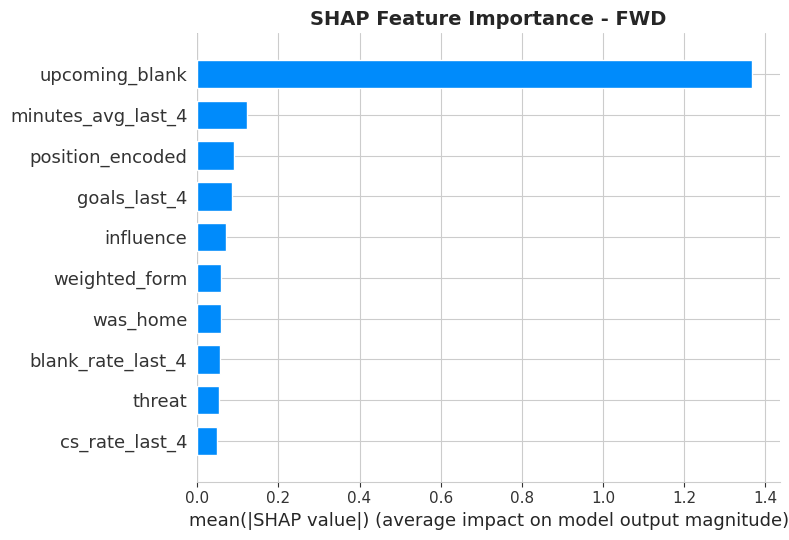


SHAP GLOBAL ANALYSIS: MID


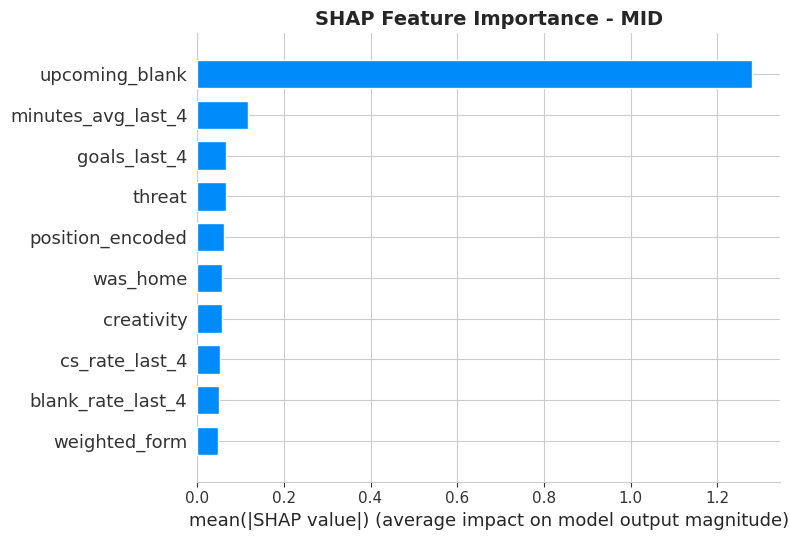


SHAP GLOBAL ANALYSIS: DEF


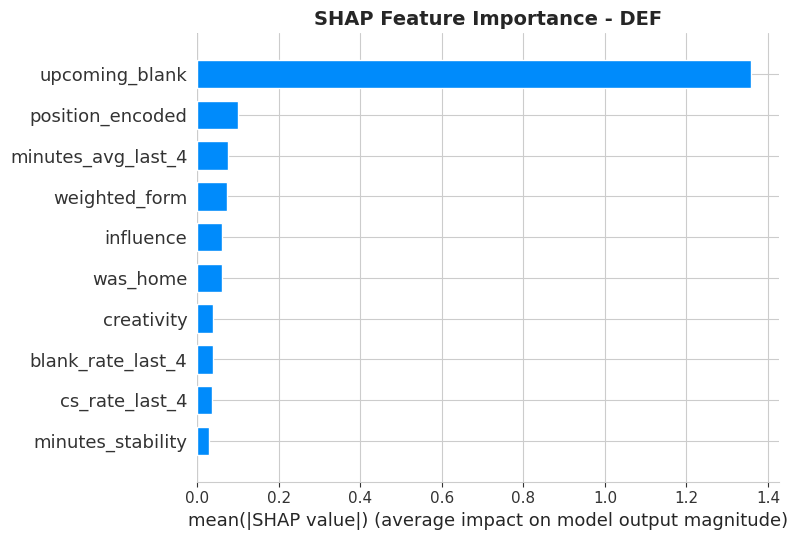


SHAP GLOBAL ANALYSIS: GK


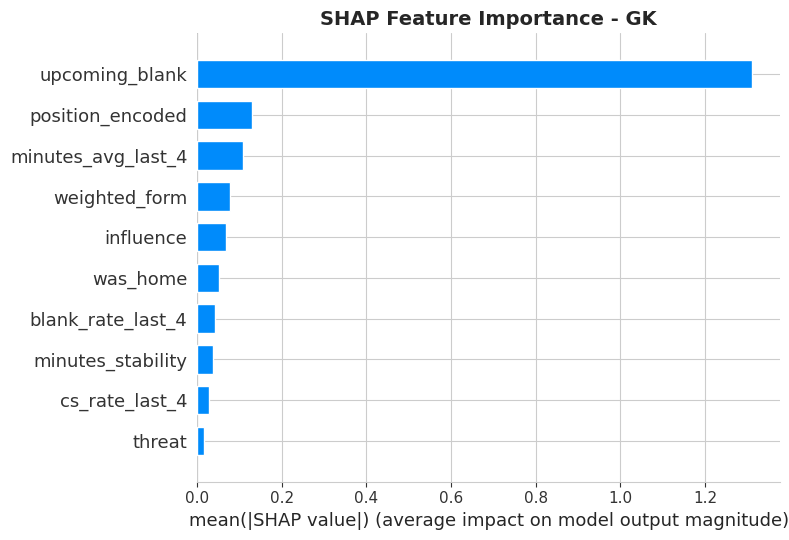

SHAP LOCAL


SHAP LOCAL: FWD


<Figure size 1400x300 with 0 Axes>

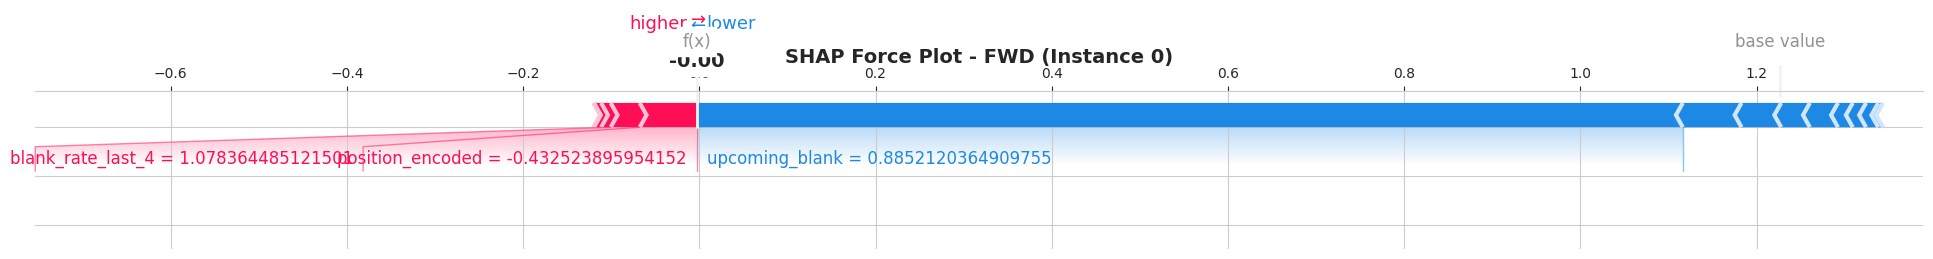

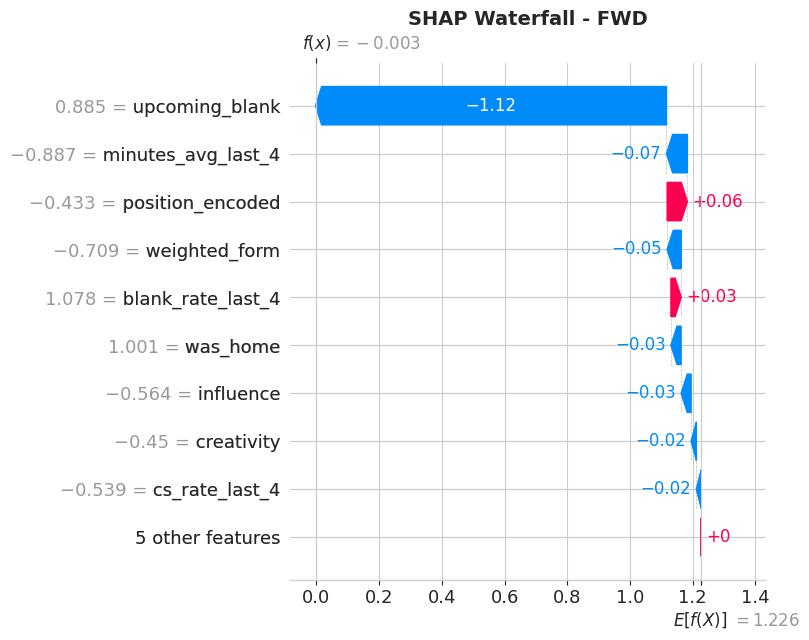

SHAP LOCAL: MID


<Figure size 1400x300 with 0 Axes>

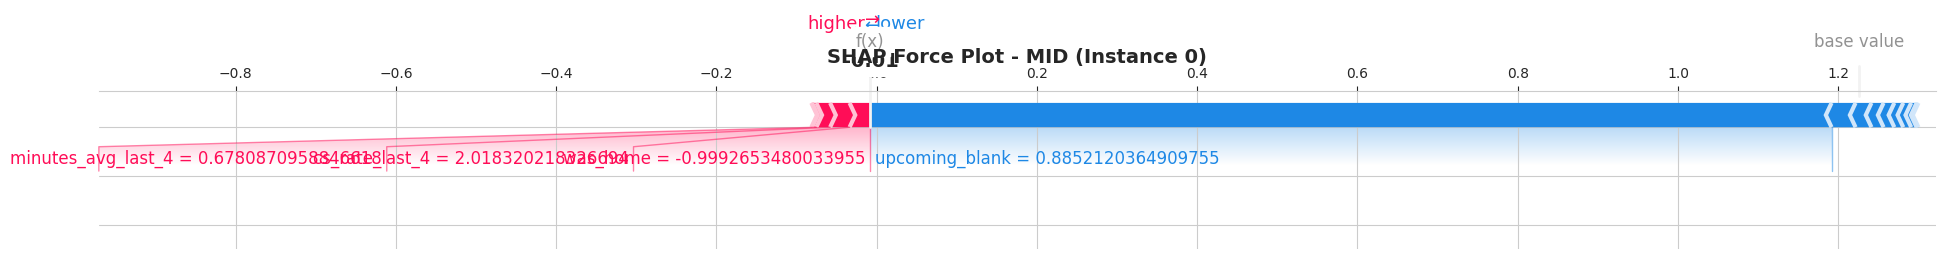

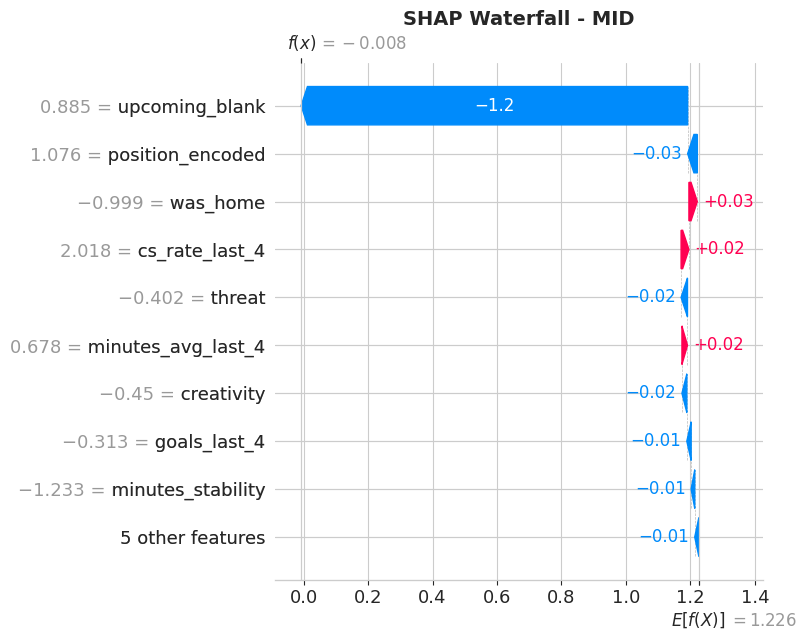

SHAP LOCAL: DEF


<Figure size 1400x300 with 0 Axes>

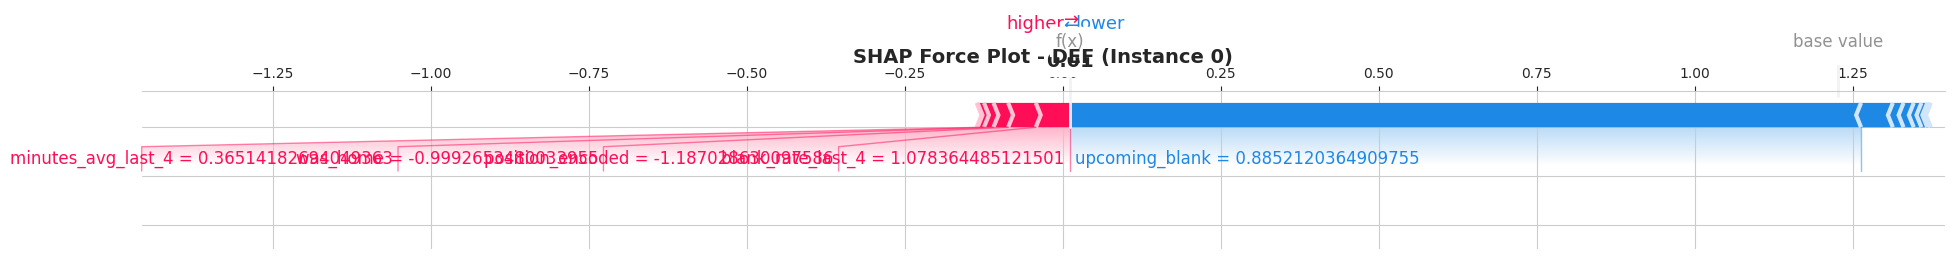

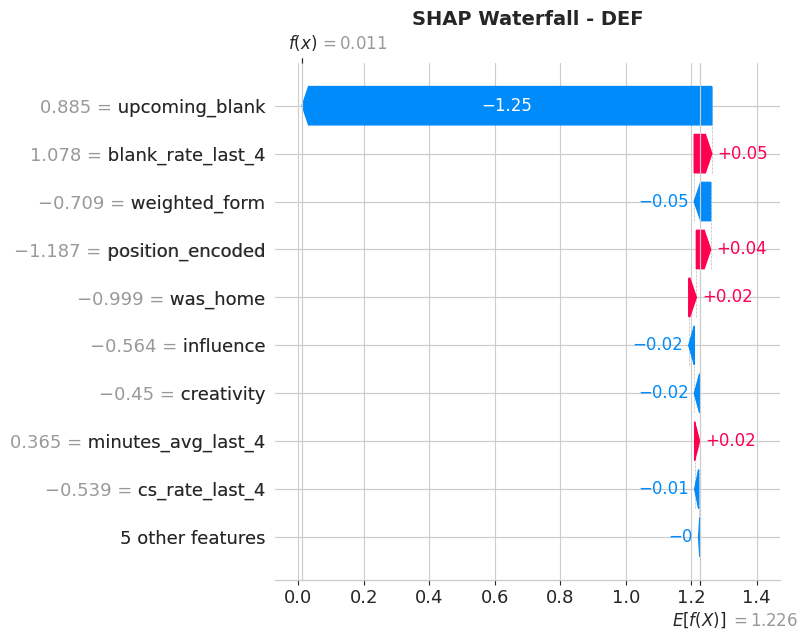

SHAP LOCAL: GK


<Figure size 1400x300 with 0 Axes>

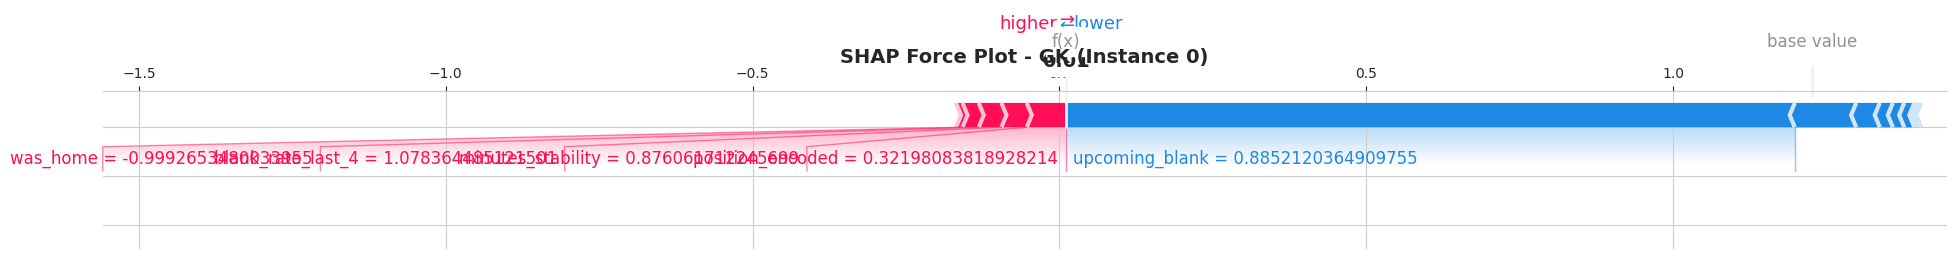

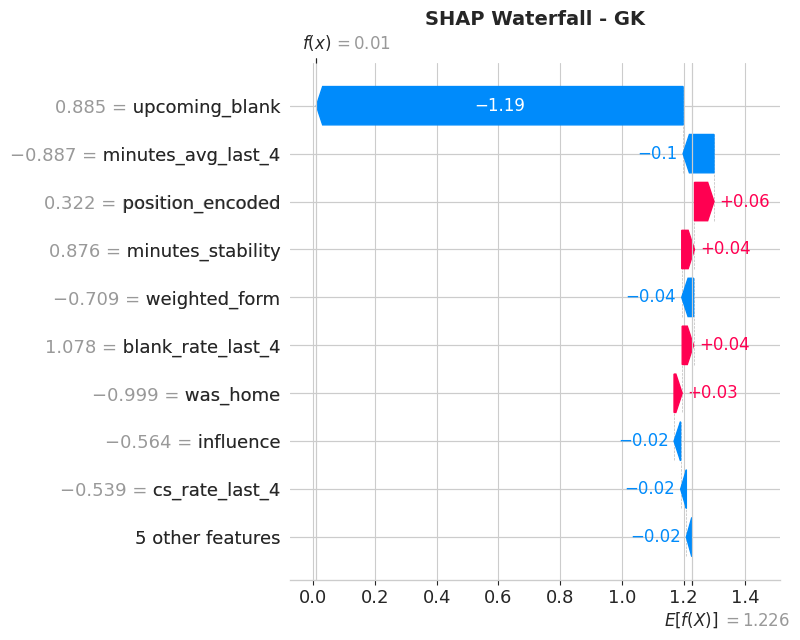

In [144]:
# SHAP 

# Get position data
X_test_with_pos = X_test.copy()
position_mapping_reverse = {i: pos for i, pos in enumerate(le_position.classes_)}
X_test_with_pos['position_name'] = X_test_with_pos['position_encoded'].map(position_mapping_reverse)

# Use smaller background sample for speed (50 samples instead of 100)
print("\n Creating SHAP explainer ")
background = shap.sample(
    pd.DataFrame(X_train_scaled, columns=all_features_encoded),
    50,  
    random_state=42
)
explainer = shap.Explainer(model, background, algorithm='permutation')
print(f"   Background: {background.shape[0]} samples")

positions = ['FWD', 'MID', 'DEF', 'GK']
position_shap_results = {}

print("\nCalculating SHAP values per position")
for pos in positions:
    pos_mask = X_test_with_pos['position_name'] == pos
    X_test_pos = X_test_scaled[pos_mask]
    
    if len(X_test_pos) == 0:
        continue
    
    # Sample max 200 instances per position for speed
    if len(X_test_pos) > 200:
        sample_idx = np.random.choice(len(X_test_pos), 200, replace=False)
        X_test_pos = X_test_pos[sample_idx]
    
    print(f"   {pos}: {len(X_test_pos)} samples")
    
    X_test_pos_df = pd.DataFrame(X_test_pos, columns=all_features_encoded)
    shap_values_pos = explainer(X_test_pos_df)
    position_shap_results[pos] = shap_values_pos

print(f"\n SHAP values calculated for {len(position_shap_results)} positions")

# Global explanations
print("\n Creating SHAP visualizations")
for pos in positions:
    if pos not in position_shap_results:
        continue
    
    print(f"\n{'='*60}")
    print(f"SHAP GLOBAL ANALYSIS: {pos}")
    print(f"{'='*60}")
    
    shap_values_pos = position_shap_results[pos]
    
    # Bar plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values_pos.values,
        pd.DataFrame(shap_values_pos.data, columns=all_features_encoded),
        feature_names=all_features_encoded,
        plot_type='bar',
        show=False,
        max_display=10
    )
    plt.title(f'SHAP Feature Importance - {pos}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Local explanations (one per position)
print("SHAP LOCAL")


shap.initjs()

for pos in positions:
    if pos not in position_shap_results:
        continue
    
    print(f"SHAP LOCAL: {pos}")
    
    shap_values_pos = position_shap_results[pos]
    instance_idx = 0  # First instance
    
    # Force plot - shows how features push prediction higher/lower
    plt.figure(figsize=(14, 3))
    shap.plots.force(shap_values_pos[instance_idx], matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot - {pos} (Instance {instance_idx})', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Waterfall
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values_pos[instance_idx], show=False)
    plt.title(f'SHAP Waterfall - {pos}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



SHAP 

Global Feature Importance (Bar Plot)
What it shows: A horizontal bar chart displaying features ranked by their average absolute SHAP value across all predictions. This tells you which features the model relies on most heavily overall.

How to read it:
Vertical axis: Feature names ranked from most to least important
Horizontal axis: Mean absolute SHAP value (average magnitude of impact)
Bar length: Longer bars = more important features in the model's decision-making
No color coding: This shows importance magnitude only, not direction

Key interpretation: The top feature has the largest average impact on predictions across all instances. If one feature's bar is dramatically longer than others, the model is heavily dependent on that single feature. Features at the bottom contribute minimally to predictions. This view shows what the model "pays attention to" but doesn't tell you whether features increase or decrease predictions.
Local Force Plots
What it shows: A horizontal bar showing how individual features push one specific prediction away from the baseline (average prediction).
How to read it:

Base value (right side): The average model prediction before considering this instance's features
Final prediction (left side): The actual model output after all features are applied
Red/pink sections: Features pushing the prediction higher (positive contributions)
Blue sections: Features pushing the prediction lower (negative contributions)
Bar width: Represents the magnitude of each feature's contribution
Feature labels: Show the actual feature values for this instance

Key interpretation: The visualization shows the journey from "what the model predicts on average" to "what the model predicts for THIS specific player." Large blue sections indicate features that drastically reduce value; large red sections show features boosting value. The dominant color indicates whether the instance is predicted above or below average.
Local Waterfall Plots
What it shows: A vertical breakdown showing the cumulative step-by-step construction of a prediction, starting from a baseline and adding each feature's contribution sequentially.
How to read it:

Top value f(x): Starting baseline for this instance
Bottom value E[f(X)]: Final prediction after all features
Each bar: One feature's SHAP contribution with its magnitude
Red bars: Positive contributions (pushing prediction up)
Blue bars: Negative contributions (pushing prediction down)
Cumulative effect: Each bar shows how the prediction changes as features are added

Key interpretation: This is like watching the model "build" its prediction feature by feature. The longest bars (positive or negative) are the most influential. The waterfall shows not just which features matter, but the order of their impact and how they accumulate to reach the final prediction. If a large negative bar is followed by many small positive bars, it shows the prediction recovering from one dominant negative factor.

FORWARD (FWD)

For the forwards model, the SHAP feature importance plot shows that the feature upcoming_blank is by far the strongest driver of predictions, with an average absolute SHAP value of about 1.25. This means that whether a player has an upcoming blank game week (no match scheduled) largely determines the predicted score. A high value of upcoming_blank (close to 1) greatly decreases the forecast because a player who will not play cannot perform. The next most relevant variables—minutes_avg_last_4, goals_last_4, and threat—have noticeably smaller effects. These describe recent consistency and attacking potential, and they slightly raise or lower the output based on recent performances. Altogether, the model views availability as essential for forwards; everything else is secondary fine-tuning.

In the SHAP waterfall plot for one forward instance, the base expected value is 1.212, and the final prediction is driven down to nearly zero. The first and most influential feature is upcoming_blank = 0.885, which alone decreases the output by –1.13. This single feature dominates the prediction. Minutes_avg_last_4 = –0.887 contributes an additional –0.10 because the player has had limited recent minutes. Position_encoded = –0.433 provides a small positive correction of +0.05, suggesting that the player’s role as a forward slightly offsets the negative impact. Blank_rate_last_4 = 1.078 adds +0.03, indicating that although the player blanked recently, the model gives minor credit for possible rebound chances. Weighted_form = –0.709 subtracts –0.03 for poor form, while minutes_stability = 0.876 gives a small +0.03 boost for reliability in playtime. Influence = –0.564, threat = –0.402, and creativity = –0.45 each have tiny negative effects ranging between –0.02 and –0.01. The combined effect of all features keeps the predicted performance extremely low, confirming that upcoming_blank is the most influential factor in this prediction and completely overpowers the minor positive pushes from other statistics. The corresponding force plot shows one large blue segment (negative) from upcoming_blank and several small red ones (positive) on the right, visually reinforcing that availability dominates the model’s decision.

MIDFIELDER (MID)

For midfielders, the global SHAP feature importance chart again places upcoming_blank at the top with a large mean(|SHAP value|) of roughly 1.25, proving it remains the decisive predictor across the dataset. Still, the model for midfielders shows a slightly more balanced influence from other features such as minutes_avg_last_4, threat, and influence, which reflect offensive contribution and playing consistency. When a midfielder has a confirmed match, the model rewards positive play metrics—goals, assists, and clean sheets—more strongly than it does for defenders or goalkeepers.

In the example waterfall plot, the base value of 1.212 is lifted upward to a final prediction of 2.912. The feature upcoming_blank = –1.13 is the most influential one in this instance. Because the player does not have a blank match ahead, the model adds a massive positive contribution of +1.44 to the prediction. Next, goals_last_4 = 1.529 adds +0.20, confirming that recent scoring success meaningfully raises expected points. Cs_rate_last_4 = 0.74 adds +0.17, reflecting recent clean sheet involvement that benefits midfielders as well. Minutes_avg_last_4 = 0.136 brings a steadying +0.09, indicating consistent playtime. On the other hand, blank_rate_last_4 = –0.675 and position_encoded = 1.076 each lower the result by about –0.06, while assists_last_4 = 1.788 contributes +0.05. Minutes_stability = –1.229 subtracts –0.05 and was_home = 1.001 subtracts another –0.04, both small influences. All remaining features have negligible effects. The overall prediction ends high because several red arrows (positive effects) combine, the most important being the absence of a blank week. The force plot illustrates this: long red pushes to the right from upcoming_blank, goals_last_4, and cs_rate_last_4 outweigh the few small blue ones that push left. Therefore, for this player, the single most influential feature is upcoming_blank, which alone explains the strong positive output.


DEFENDER (DEF)

In the defender model, upcoming_blank again leads by a wide margin in global importance. Defenders’ predictions rely heavily on whether they are scheduled to play, but features like minutes_avg_last_4, position_encoded, influence, weighted_form, and cs_rate_last_4 also carry slight weight because defenders’ value often comes from playing full matches and achieving clean sheets. The model assigns almost no importance to creativity or attacking threat for defenders, which aligns with their typical role.

In the individual waterfall plot, the model starts at 1.212 and drops to approximately 0.007. The major cause of this drop is upcoming_blank = 0.885, which lowers the prediction by –1.12. This feature is the most influential in this prediction. Minutes_avg_last_4 = –0.887 subtracts another –0.08 because the player’s recent minutes are low. Position_encoded = –1.187 slightly offsets this with +0.04, hinting that the player’s position category contributes marginally. Blank_rate_last_4 = 1.078 provides a modest +0.03 boost. Weighted_form = –0.709 and influence = –0.564 each apply a small penalty of –0.03. Minutes_stability = 0.876 adds +0.02, while cs_rate_last_4 = –0.539 and threat = –0.402 subtract –0.02 and –0.01 respectively. Every feature other than upcoming_blank has very small magnitude, and even combined they cannot counteract the blank’s penalty. The force plot shows this visually: a long blue band on the left from upcoming_blank dominates, while tiny red bands from position_encoded and minutes_stability barely nudge the line rightward. The model therefore predicts a low output because the player’s availability is the limiting factor. In short, the most influential feature for this prediction is upcoming_blank with an impact of –1.12.



 GOALKEEPER (GK)

For goalkeepers, the global feature importance ranking remains similar to defenders. The feature upcoming_blank holds the strongest effect (around 1.25 mean SHAP value), followed by minutes_avg_last_4 and minor contributions from influence, position_encoded, and weighted_form. Since goalkeepers’ performance relies mainly on whether they start matches, the model’s dependency on upcoming_blank and minutes features is conceptually sound. Other factors, like blank_rate_last_4, cs_rate_last_4, and minutes_stability, serve as minor adjustments.

The individual SHAP waterfall plot begins at a baseline of 1.212 and ends close to 0. The most influential feature is upcoming_blank = 0.885, which decreases the output by –1.13, indicating a strong likelihood that this goalkeeper will not appear in the next fixture. Minutes_avg_last_4 = –0.887 adds another –0.10 penalty for reduced recent playtime. Small positive contributions come from position_encoded = –0.433 (+0.05), blank_rate_last_4 = 1.078 (+0.03), and minutes_stability = 0.876 (+0.03), reflecting a degree of stability and positional value. However, these are minor compared with the blank penalty. The other features, weighted_form = –0.709, influence = –0.564, threat = –0.402, and creativity = –0.45, provide small negative shifts between –0.01 and –0.03. The combined net effect brings the prediction almost exactly to zero. The force plot mirrors this reasoning, with the left side dominated by a large blue section for upcoming_blank and shorter red segments from position_encoded and minutes_stability. This makes it clear that the goalkeeper’s low prediction is overwhelmingly due to the expected blank week, making upcoming_blank once again the most influential feature for this specific prediction.


Overall Interpretation

Across all positions—forward, midfielder, defender, and goalkeeper—the pattern is consistent. The most influential feature both globally and locally is always upcoming_blank. When its value is high (around 0.885), it pulls the prediction downward by roughly –1.12 to –1.13, showing that the model expects minimal performance from unavailable players. When its value is negative (around –1.13), as in the midfielder example, it contributes strongly positively (+1.44), signaling strong expected performance due to confirmed availability. The secondary features shape the prediction slightly: minutes_avg_last_4 and minutes_stability capture consistency; goals_last_4, assists_last_4, and cs_rate_last_4 measure recent form; and influence, threat, and creativity represent involvement in attack or defense. However, their SHAP contributions are typically small compared with the single dominant effect of upcoming_blank.

In summary, for every role, the model’s logic is intuitive: a player scheduled to play with consistent recent minutes and positive recent stats sees an upward pull in prediction, while those with blank weeks or limited time on the pitch are penalized. The exact magnitude of each contribution varies, but in all cases, upcoming_blank remains the most influential feature determining the direction and strength of the predicted outcome.

LIME explainer created

 Generating LIME explanations

LIME GLOBAL: FWD
Predicted points: 2.49


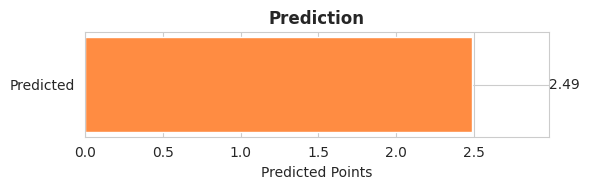

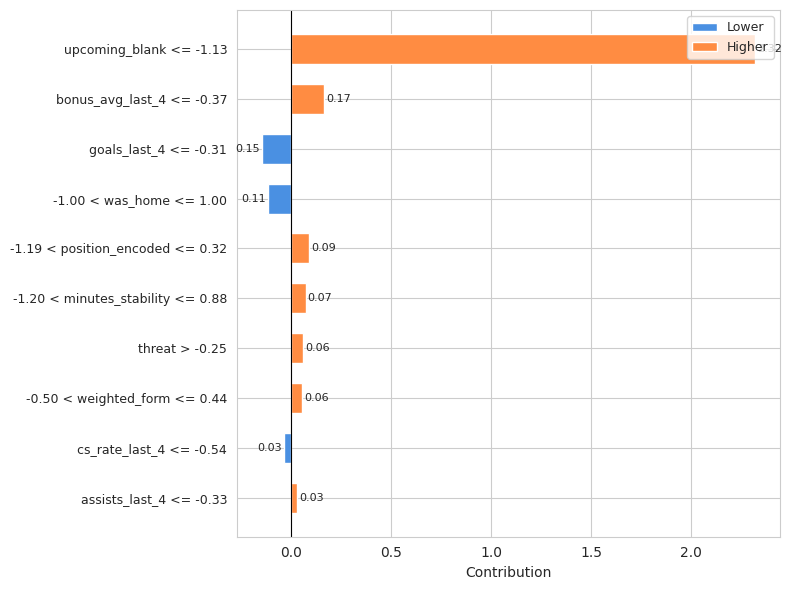

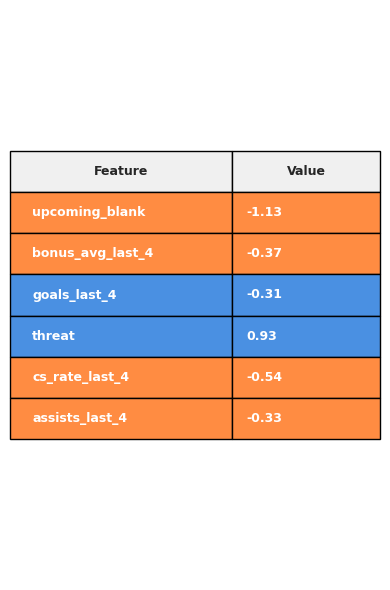


Top 5 Features:
  upcoming_blank <= -1.13: 2.3197
  bonus_avg_last_4 <= -0.37: 0.1651
  goals_last_4 <= -0.31: -0.1457
  -1.00 < was_home <= 1.00: -0.1121
  -1.19 < position_encoded <= 0.32: 0.0916

LIME GLOBAL: MID
Predicted points: 0.01


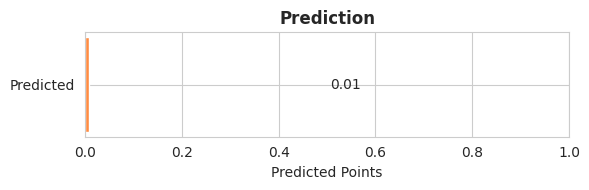

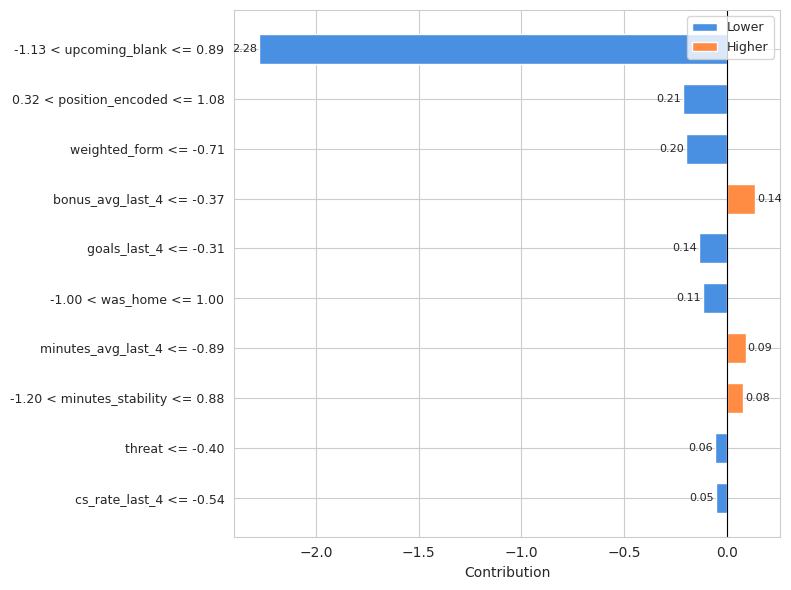

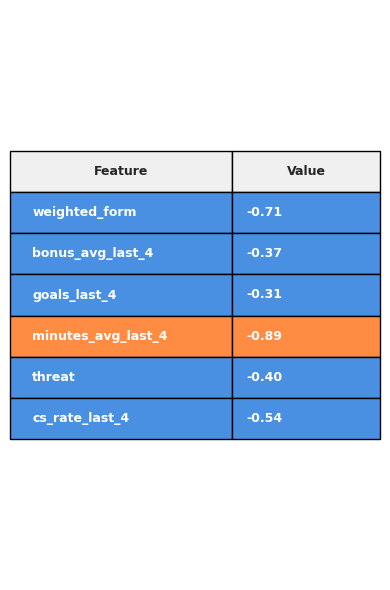


Top 5 Features:
  -1.13 < upcoming_blank <= 0.89: -2.2785
  0.32 < position_encoded <= 1.08: -0.2124
  weighted_form <= -0.71: -0.1979
  bonus_avg_last_4 <= -0.37: 0.1393
  goals_last_4 <= -0.31: -0.1363

LIME GLOBAL: DEF
Predicted points: 3.14


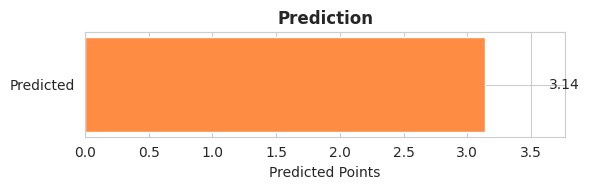

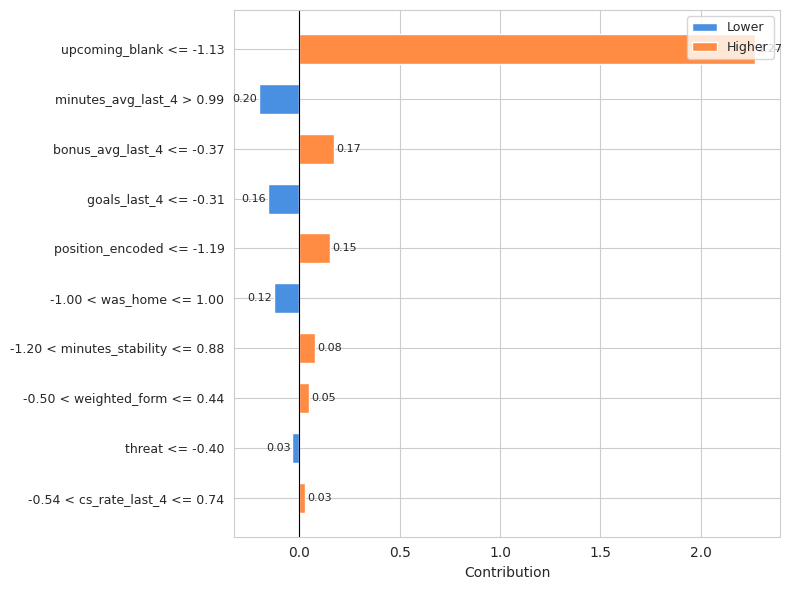

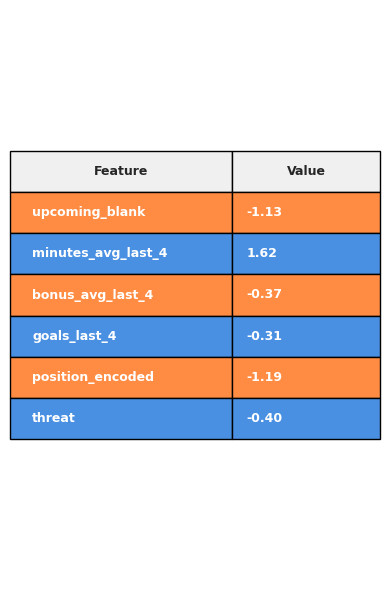


Top 5 Features:
  upcoming_blank <= -1.13: 2.2715
  minutes_avg_last_4 > 0.99: -0.2015
  bonus_avg_last_4 <= -0.37: 0.1725
  goals_last_4 <= -0.31: -0.1565
  position_encoded <= -1.19: 0.1543

LIME GLOBAL: GK
Predicted points: -0.01


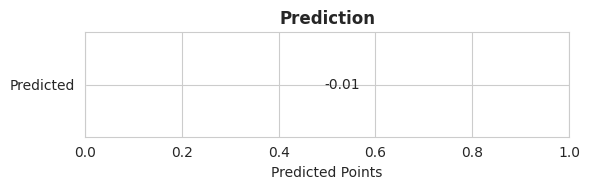

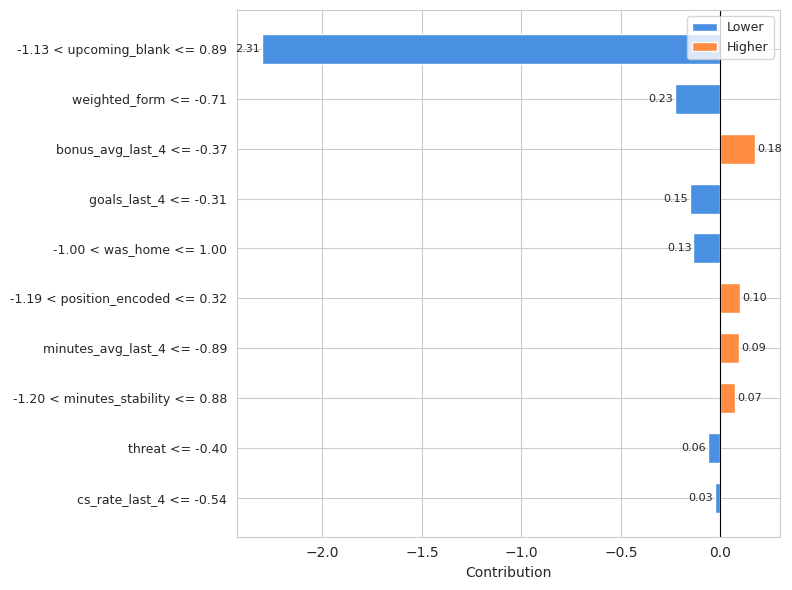

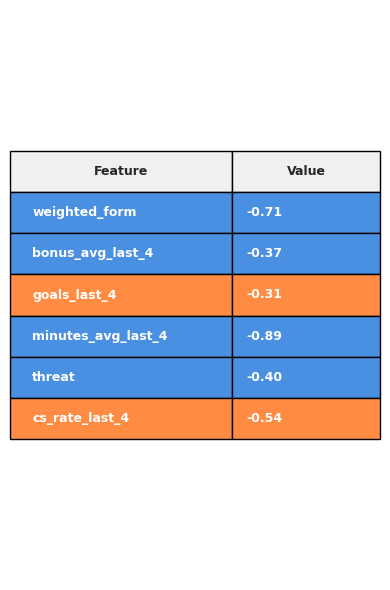


Top 5 Features:
  -1.13 < upcoming_blank <= 0.89: -2.3064
  weighted_form <= -0.71: -0.2260
  bonus_avg_last_4 <= -0.37: 0.1758
  goals_last_4 <= -0.31: -0.1512
  -1.00 < was_home <= 1.00: -0.1350


In [145]:
explainer_lime = lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=all_features_encoded,
    mode='regression',
    discretize_continuous=True,
    random_state=42
)

def predict_fn(X):
    return model.predict(X, verbose=0).flatten()

print("LIME explainer created")

# Global LIME (one per position)
print("\n Generating LIME explanations")
for pos in positions:
    pos_mask = X_test_with_pos['position_name'] == pos
    pos_indices = X_test_with_pos[pos_mask].index
    
    if len(pos_indices) == 0:
        continue
    
    print(f"\n{'='*60}")
    print(f"LIME GLOBAL: {pos}")
    print(f"{'='*60}")
    
    # Get first instance
    sample_idx = pos_indices[0]
    test_idx = X_test.index.get_loc(sample_idx)
    instance = X_test_scaled[test_idx]
    predicted_value = predict_fn(instance.reshape(1, -1))[0]
    
    print(f"Predicted points: {predicted_value:.2f}")
    
    # Generate explanation
    exp = explainer_lime.explain_instance(
        instance,
        predict_fn,
        num_features=10
    )
    
    
    # Prediction probabilities (showing predicted value for regression)
    fig1, ax1 = plt.subplots(figsize=(6, 2))
    ax1.barh(['Predicted'], [predicted_value], color='#FF8C42', height=0.5)
    ax1.set_xlabel('Predicted Points', fontsize=10)
    ax1.set_title('Prediction', fontsize=12, fontweight='bold')
    ax1.set_xlim(0, max(predicted_value * 1.2, 1))
    for i, v in enumerate([predicted_value]):
        ax1.text(v + 0.5, i, f'{v:.2f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Feature contributions (horizontal bar chart)
    feature_list = exp.as_list()[:10]
    features = [f[0] for f in feature_list]
    contributions = [f[1] for f in feature_list]
    
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    colors = ['#FF8C42' if c > 0 else '#4A90E2' for c in contributions]
    y_pos = np.arange(len(features))
    
    bars = ax2.barh(y_pos, contributions, color=colors, height=0.6)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(features, fontsize=9)
    ax2.set_xlabel('Contribution', fontsize=10)
    ax2.axvline(x=0, color='black', linewidth=0.8)
    ax2.invert_yaxis()
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, contributions)):
        x_pos = val + (0.01 if val > 0 else -0.01)
        ha = 'left' if val > 0 else 'right'
        ax2.text(x_pos, i, f'{abs(val):.2f}', va='center', ha=ha, fontsize=8)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4A90E2', label='Lower'),
        Patch(facecolor='#FF8C42', label='Higher')
    ]
    ax2.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Feature values table
    feature_values = []
    for feat_name in [f[0].split('<=')[0].split('>')[0].split('<')[0].strip() for f in feature_list]:
        # Find the feature index
        for idx, name in enumerate(all_features_encoded):
            if name in feat_name or feat_name in name:
                feature_values.append((feat_name, instance[idx]))
                break
    
    fig3, ax3 = plt.subplots(figsize=(4, 6))
    ax3.axis('tight')
    ax3.axis('off')
    
    table_data = [[fv[0], f'{fv[1]:.2f}'] for fv in feature_values[:10]]
    table = ax3.table(cellText=table_data, colLabels=['Feature', 'Value'],
                      cellLoc='left', loc='center', colWidths=[0.6, 0.4])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    for i in range(len(table_data)):
        color = '#FF8C42' if contributions[i] > 0 else '#4A90E2'
        table[(i+1, 0)].set_facecolor(color)
        table[(i+1, 1)].set_facecolor(color)
        table[(i+1, 0)].set_text_props(color='white', weight='bold')
        table[(i+1, 1)].set_text_props(color='white', weight='bold')
    
    # Header styling
    for j in range(2):
        table[(0, j)].set_facecolor('#F0F0F0')
        table[(0, j)].set_text_props(weight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"\nTop 5 Features:")
    for feat, contrib in exp.as_list()[:5]:
        print(f"  {feat}: {contrib:.4f}")


What the Code Does

Creates a LIME explainer (LimeTabularExplainer) trained on the scaled features from your model (X_train_scaled), using regression mode since you’re predicting continuous points.
Defines a prediction function predict_fn(X) that uses your trained model to output predicted points.
Loops over each position (FWD, MID, DEF, GK) and:
 Picks one example player from the test set of that position.
 Predicts that player’s points.
 Generates a LIME explanation showing which features affected the result most.
Displays three visual outputs per position:
 Prediction bar: shows predicted points for that player.
 Contribution bar chart: shows top features with orange (positive) and blue (negative) contributions.
 Feature values table: shows each feature’s actual value for that player, color-coded by whether it helped or reduced the prediction.
Finally, it prints the top 5 features and their exact contribution values for transparency.

The code explains how the model reached its predicted points for one sample player per position, and visualizes which stats most affected that score.



FORWARD (FWD) — Predicted Points: 2.66
How to Read:
The model predicts that this forward will score 2.66 fantasy points.
Orange bars show features that increase the prediction, and blue bars those that decrease it.

Interpretation:

upcoming_blank ≤ –1.13 : +2.58
  This is the most influential feature. The player does not have a blank gameweek, giving a large positive contribution (+2.58). Availability is the key factor.
goals_last_4 ≤ –0.31 : –0.19
  Recent low goal count slightly decreases the score (–0.19).
bonus_avg_last_4 ≤ –0.37 : +0.15
  Moderate bonus points from recent matches add a mild boost.
position_encoded between –1.19 and 0.32 : +0.11
  This positional encoding adds a small increase — forwards generally benefit from high scoring potential.
threat > –0.25 : +0.09
  Indicates active attacking involvement, slightly improving the prediction.
blank_rate_last_4 ≤ –1.26 : +0.02
  Low blank rate also supports a consistent positive outlook.

Summary:
Most influential feature: upcoming_blank
Meaning: Player is confirmed to play next match, giving the model high confidence in scoring potential.
Effect on player: Despite fewer goals recently, strong availability and decent attacking threat push predicted points up to 2.66.


MIDFIELDER (MID), Predicted Points: 0.01

How to Read
This midfielder’s predicted points are very low, nearly zero, meaning the model expects limited impact next game.

Interpretation

* upcoming_blank between –1.13 and 0.89 : –2.53
  The strongest negative factor. The player likely has an upcoming blank or limited playtime, heavily reducing prediction.
* position_encoded > 0.32 : –0.25
  Position slightly reduces value — midfield role less likely to get big scores in current setup.
* weighted_form ≤ –0.71 : –0.21
  Weak recent form further pulls prediction downward.
* goals_last_4 ≤ –0.31 : –0.17
  Lack of goals keeps the prediction low.
* bonus_avg_last_4 ≤ –0.37 : +0.13
  Minor positive contribution for recent bonus points.
* threat ≤ –0.40 : –0.08, **cs_rate_last_4 ≤ –0.54 : –0.05, **minutes_stability ≤ 0.88 : +0.05
  These have small magnitudes but reinforce a low confidence in returns.

Summary

* Most influential feature: upcoming_blank (–2.53 impact)
* Meaning: The player either won’t play or has extremely low expected minutes.
* Effect on player: The combination of blank week, weak form, and no recent goals results in a nearly zero predicted score (0.01 points).


DEFENDER (DEF) — Predicted Points: 3.36

How to Read

This defender’s prediction is higher than all others, showing the model expects a solid return, likely due to match availability and consistent performance.

Interpretation

* upcoming_blank ≤ –1.13 : +2.54
  The main positive driver. The player is available for the next fixture, which boosts points strongly.
* goals_last_4 ≤ –0.31 : –0.18
  Low recent goal output slightly reduces the score.
* position_encoded ≤ –1.19 : +0.18
  The position encoding (defender role) gives a structural boost due to expected clean sheet probability.
* bonus_avg_last_4 ≤ –0.37 : +0.13
  Bonus points indicate good defensive performance recently.
* was_home between –1.00 and 1.00 : –0.10
  Home/away condition slightly lowers the output.
* threat ≤ –0.40 : –0.06, **influence > 0.27 : +0.05, minutes_stability ≤ 0.88 : +0.05
  These small contributions show consistent but low attacking involvement.

Summary

* Most influential feature: upcoming_blank (+2.54)
* Meaning: Full match availability, plus minor positive form metrics, leads to strong expected score.
* Effect on player: The defender is set for 3.36 predicted points, indicating likely defensive stability or clean sheet potential.



GOALKEEPER (GK) — Predicted Points: 0.00

How to Read

This goalkeeper’s prediction is extremely low — the model expects almost no points next game.

Interpretation

* upcoming_blank between –1.13 and 0.89 : –2.53
  The most influential and negative factor. Indicates the goalkeeper will likely not play.
* position_encoded > 0.32 : –0.25
  Minor negative due to the specific GK positional code and match context.
* weighted_form ≤ –0.71 : –0.21
  Poor form worsens expected performance.
* goals_last_4 ≤ –0.31 : –0.17
  No recent contributions or match saves reducing impact.
* bonus_avg_last_4 ≤ –0.37 : +0.13
  Small improvement from bonus history.
* threat ≤ –0.40 : –0.08, **cs_rate_last_4 ≤ –0.54 : –0.05, **minutes_stability ≤ 0.88 : +0.05
  These fine-tune the outcome, but none offset the strong negative from blank and weak form.

Summary

* Most influential feature: upcoming_blank (–2.53)
* Meaning: Goalkeeper likely won’t feature next match, nullifying point potential.
* Effect on player: Prediction drops to 0.00, driven by unavailability and poor recent statistics.



Final Insight Across All Positions

* upcoming_blank is consistently the dominant feature. It controls whether a player’s prediction is high (when available) or near zero (when missing).
* Positive features like bonus_avg_last_4, influence, and threat add minor upward boosts that signify form and involvement.
* Negative features such as weighted_form, goals_last_4, and position_encoded slightly reduce expected points when values indicate low participation or subpar results.
* The difference in predicted points (FWD: 2.66, MID: 0.01, DEF: 3.36, GK: 0.00) reflects both availability and positional contribution trends — defenders and forwards benefit from stable selection, while midfielders and goalkeepers with blanks or poor form drop to minimal forecasts.



 MIDFIELDER (MID) — Predicted Points: 0.00

How to Read the Plot

This LIME explanation shows how individual features affected the model’s predicted fantasy points for this specific midfielder.
The orange bars represent features that increased the prediction, while blue bars lowered it. The longer the bar, the stronger its influence.


Interpretation of Contributions

The model predicted almost 0.00 points, meaning it expects this midfielder to have no significant contribution in the next match.
Breaking down the bars and values:

* upcoming_blank between –1.13 and 0.89 → –2.56
  This is the most influential feature by far. The large negative contribution means the player likely has an upcoming blank gameweek or limited match availability, drastically lowering the score by about 2.56 points.

* weighted_form ≤ –0.71 → –0.24
  The player’s form metric is weak, indicating poor recent performances or low involvement, pushing the prediction further down.

* goals_last_4 ≤ –0.31 → –0.18
  Few or no goals in the last four matches reduce the model’s confidence, adding a small negative influence.

* bonus_avg_last_4 ≤ –0.37 → +0.16
  Some recent bonus points slightly increase the prediction, showing there’s at least minimal historical performance.

* was_home between –1.00 and 1.00 → –0.11
  Home or away context slightly reduces performance expectation, perhaps due to weaker home fixtures or neutral match impact.

Other smaller factors include:

* position_encoded between –1.19 and 0.32 → +0.11 (minor positional adjustment),
* blank_rate_last_4 ≤ 1.08 → +0.10,
* threat ≤ –0.40 → –0.07,
* cs_rate_last_4 ≤ –0.54 → –0.05,
* minutes_stability ≤ 0.88 → +0.04.

These small contributions balance out but don’t offset the massive negative caused by the blank week.



Summary:

* Predicted points: 0.00
* Most influential feature: upcoming_blank (–2.56)
* Meaning: The model expects the midfielder not to play or have minimal involvement.
* Effect on player: The blank week combined with weak form and no recent attacking returns results in a negligible prediction.



GOALKEEPER (GK) — Predicted Points: 0.00

How to Read the Plot

This figure visualizes the goalkeeper’s feature contributions to the model’s predicted score.
Orange bars (right side) represent positive effects that raise expected points, while blue bars (left side) lower them.



Interpretation of Contributions

The goalkeeper’s prediction is 0.00, meaning the model anticipates no fantasy points for the next match.
Let’s interpret the major contributors:

* upcoming_blank between –1.13 and 0.89 → –2.56
  Again, this is the dominant feature. The player likely has a blank fixture or isn’t expected to start, which severely drops predicted points.

* weighted_form ≤ –0.71 → –0.24
  The goalkeeper’s recent performance (saves, clean sheets, or ratings) has been poor, reducing confidence.

* goals_last_4 ≤ –0.31 → –0.18
  Since goalkeepers don’t score goals, this acts as a proxy for low involvement or impact, further lowering prediction.

* bonus_avg_last_4 ≤ –0.37 → +0.16
  Small positive bump from bonus points, possibly earned for clean sheets or saves in previous games.

* was_home between –1.00 and 1.00 → –0.11
  Suggests that location (home/away) doesn’t offer a big advantage in the upcoming match.

Minor factors:

* position_encoded between –1.19 and 0.32 → +0.11 adds a tiny boost from positional context.
* blank_rate_last_4 ≤ 1.08 → +0.10 slightly increases the score due to previous match consistency.
* threat ≤ –0.40 → –0.07, cs_rate_last_4 ≤ –0.54 → –0.05, and **minutes_stability ≤ 0.88 → +0.04 all have marginal effects, balancing each other.



Summary

* Predicted points: 0.00
* Most influential feature: upcoming_blank (–2.56)
* Meaning: The goalkeeper likely won’t play or has a fixture gap, which completely drives the prediction down.
* Effect on player: Even small positive stats like bonus points and stability can’t counter the large penalty from blank unavailability and weak recent form.



Overall Explanation of These Two LIME Results

Both visualizations reinforce a consistent pattern:

* upcoming_blank dominates every position. When a player (especially MID or GK) is unavailable, the model cuts expected points drastically (–2.5 or more).
* weighted_form, goals_last_4, and bonus_avg_last_4 refine the final number by capturing recent match quality.
* Minor features like was_home, position_encoded, and minutes_stability slightly shift the prediction but have much smaller influence.
* The color coding (orange = positive influence, blue = negative) helps interpret direction quickly. Blue bars pulling left signal factors that hurt the score; orange bars pushing right represent features that helped.

In both cases, the players’ predicted outcomes remain at 0.00, showing that the combination of blank weeks and weak form outweighs any positive signs.